# Pipeline de données RAW pour la suppression de reflets

Reproduction **simplifiée** de la génération de données de *Removing Reflections
from RAW Photos* (Kee, Pikielny, Blackburn-Matzen, Levoy — CVPR 2025), en
utilisant uniquement le dataset **MIT-Adobe FiveK**.

**Idée clé du papier** : la lumière s'additionne linéairement sur le capteur.
Un reflet dans une vitre est donc un mélange `m = t + r` (transmission +
réflexion) — mais cette addition n'est valable que sur des images
*scene-referred* (linéaires par rapport à la luminance de la scène), **pas**
sur des JPEG tone-mappés. Le papier simule donc des reflets en additionnant
des photos RAW converties en XYZ linéaire, *avant* balance des blancs, pour
que les couleurs des illuminants se mélangent correctement.

| Étape du papier | Ici |
|---|---|
| Sources : MIT5K + RAISE + panoramas Laval | MIT-Adobe FiveK uniquement |
| ACR étapes 1–4 : linéarisation, dématriçage, niveau de noir, → XYZ | `rawpy` (LibRaw), RGB capteur → XYZ via la `ColorMatrix` du DNG |
| Dé-exposition `e = s·g/n²` (Sec. 3.1) | EXIF du DNG via `exifread` |
| Simulation géométrique : Fresnel par rayon, perspective, double réflexion, défocus calibré (Sec. 3.2 / B) | caméra + vitre échantillonnées : Fresnel exact par pixel, homographie de rotation, fantôme et défocus dérivés de l'optique |
| Photo contextuelle `c` = moitié disjointe de l'image reflet (Sec. 3.3) | idem |
| `m = t + r`, ré-exposition `e' = τ/E[m']`, WB partagée dans XYZ (Func. 1) | idem, WB = illuminant *as-shot* de la transmission (CAT Bradford → D50) |
| Recherche de mélanges « utiles » parmi 10⁸ candidats + priors sémantiques (Sec. D) | scoring de paires réalistes (catégories FiveK + illuminants) + heuristiques de filtrage |
| Sortie : (m, t, r, c) en sRGB linéaire, 256p et 2048p | simulation en linéaire, puis (m, t, r, c) **finis en JPEG sRGB** 256p via notre ISP |

**Format de sortie** : la physique (`m = t + r`) n'a besoin d'être vraie
qu'*au moment de la synthèse*, en linéaire. Le dataset final est ensuite
« fini » par une pipeline ISP (tone mapping + gamma) et sauvé en **JPEG
sRGB** — des images qui ressemblent à de vraies photos JPEG, mais dont le
mélange sous-jacent était photométriquement correct. C'est l'inverse des
datasets 8 bits critiqués par le papier, qui *mélangent* directement des
images tone-mappées.


In [1]:
# Dépendances (rawpy = lecture RAW/LibRaw, exifread = métadonnées EXIF des DNG)
%pip install --quiet rawpy exifread requests tqdm opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 2.1 MB/s eta 0:00:00


In [2]:
import json
import random
from pathlib import Path

import numpy as np

DATA_DIR = Path("fivek_data")            # relatif au notebook
DNG_DIR = DATA_DIR / "dng"
OUT_DIR = DATA_DIR / "simulated"
for d in (DNG_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

N_OUTDOOR = 250          # nb de DNG "outdoor" à télécharger (~5-30 Mo chacun)
N_INDOOR = 250         # nb de DNG "indoor"
N_EXAMPLES = 500      # nb d'exemples simulés (m, t, r, c) à générer
JPEG_QUALITY = 95      # qualité des JPEG du dataset
SAVE_LINEAR = False    # True pour sauver aussi les .npz sRGB linéaire
PATCH = 512            # résolution des exemples (le papier travaille à 256p)
TAU = 0.1329    # exposition cible du pixel moyen (gris moyen, Func. S1)
MAX_SIDE = 1000        # taille max des RAW gardés en mémoire
NORMALIZE_POWER = False # voir la section simulation : ratio de puissance t/r
SEED = 1009

rng = np.random.default_rng(SEED)
rnd = random.Random(SEED)


## 1. Téléchargement d'un sous-ensemble de MIT-Adobe FiveK

On s'appuie sur les métadonnées JSON du repo
[yuukicammy/mit-adobe-fivek-dataset](https://github.com/yuukicammy/mit-adobe-fivek-dataset)
(hébergées sur Hugging Face), qui référencent les 5 000 DNG officiels de
`data.csail.mit.edu` avec leurs catégories (`location`, `time`, `light`,
`subject`) — on s'en servira pour choisir des paires réalistes.

Le papier apparie des scènes **intérieures et extérieures** (une vitre sépare
presque toujours un intérieur d'un extérieur, et leurs illuminants diffèrent) :
on télécharge donc les deux catégories. Augmente `N_OUTDOOR` / `N_INDOOR` pour
un vrai dataset — ici on reste petit pour que le notebook tourne vite.


## utils

In [3]:
import rawpy
import exifread
import cv2

In [4]:
DNG = {"ColorMatrix1": 0xC621, "ColorMatrix2": 0xC622,
       "CameraCalibration1": 0xC623, "CameraCalibration2": 0xC624,
       "AnalogBalance": 0xC627, "AsShotNeutral": 0xC628, "AsShotWhiteXY": 0xC629,
       "CalibrationIlluminant1": 0xC65A, "CalibrationIlluminant2": 0xC65B}


NOMS = {0xC621:"ColorMatrix1", 0xC622:"ColorMatrix2", 0xC623:"CameraCalibration1",
    0xC624:"CameraCalibration2", 0xC627:"AnalogBalance", 0xC628:"AsShotNeutral",
    0xC629:"AsShotWhiteXY", 0xC65A:"CalibrationIlluminant1",
    0xC65B:"CalibrationIlluminant2", 0xC65C:"BestQualityScale"}
_FLIP = {
    0: lambda a: a,                     # aucune rotation
    3: lambda a: a[::-1, ::-1],         # 180°
    5: lambda a: np.rot90(a, 1),        # 90° sens antihoraire
    6: lambda a: np.rot90(a, -1),       # 90° sens horaire
}


def dng_tag(tags, name):
    """Lit un tag DNG. exifread ne les nomme pas : on passe par l'ID hexa."""
    t = tags.get("Image Tag 0x%04X" % DNG[name])
    if t is None:
        return None
    out = []
    for v in t.values:
        out.append(float(v.num) / float(v.den) if hasattr(v, "num") else float(v))
    return np.array(out, np.float64)

def reject_noms(dng_file):
        with open(dng_file[0], "rb") as f:
            tags = exifread.process_file(f, details=False)
        asshot = dng_tag(tags,"AsShotNeutral")
        whitexy = dng_tag(tags, "AsShotWhiteXY")
        if asshot is None and whitexy is None:
            return False
        return True
            

In [5]:
import requests
from tqdm.auto import tqdm

META_URL = "https://huggingface.co/datasets/yuukicammy/MIT-Adobe-FiveK/raw/main/training.json"

meta_path = DATA_DIR / "training.json"
if not meta_path.exists():
    resp = requests.get(META_URL, timeout=120)
    resp.raise_for_status()
    meta_path.write_bytes(resp.content)
metadata = json.loads(meta_path.read_text())
print(f"{len(metadata)} images référencées")

by_loc = {}
for name, item in metadata.items():
    loc = item.get("categories", {}).get("location", "unknown")
    by_loc.setdefault(loc, []).append((name, item))
print({k: len(v) for k, v in sorted(by_loc.items())})

selection = []
for loc, n in [("outdoor", N_OUTDOOR), ("indoor", N_INDOOR)]:
    items = list(by_loc.get(loc, []))
    rnd.shuffle(items)
    selection += [(name, item, loc) for name, item in items[:n]]


def download_dng(name, item):
    url = item["urls"]["dng"].replace("http://", "https://")
    path = DNG_DIR / f"{name}.dng"
    if path.exists() and path.stat().st_size > 0:
        return path
    with requests.get(url, stream=True, timeout=300) as resp:
        resp.raise_for_status()
        tmp = path.with_suffix(".part")
        with open(tmp, "wb") as f:
            for chunk in resp.iter_content(1 << 20):
                f.write(chunk)
        tmp.rename(path)
    return path


dng_files = []  # liste de (chemin, location, catégories)
for name, item, loc in tqdm(selection, desc="DNG"):
    try:
        dng_file = ((download_dng(name, item), loc,
                          item.get("categories", {})))
        bool = reject_noms(dng_file)
        if bool:
            dng_files.append(dng_file)
    except Exception as exc:
        print(f"échec {name}: {exc}")

total_mb = sum(p.stat().st_size for p, _, _ in dng_files) / 1e6
print(f"{len(dng_files)} DNG prêts ({total_mb:.0f} Mo)")


3500 images référencées
{'indoor': 748, 'outdoor': 2513, 'unknown': 239}


DNG:   0%|          | 0/500 [00:00<?, ?it/s]

496 DNG prêts (4799 Mo)


## 2. RAW → XYZ linéaire (ACR étapes 1–4)

Le papier montre que l'étape idéale pour mélanger deux photos est la sortie de
l'étape 4 du pipeline Adobe Camera Raw : **XYZ linéaire, avant balance des
blancs**. À ce stade :

- les pixels sont proportionnels à la luminance de la scène (on peut additionner) ;
- l'espace couleur est indépendant du capteur (on peut mélanger deux appareils) ;
- la **couleur de l'illuminant est préservée** — crucial, car la scène
  transmise et la scène reflétée sont en général éclairées différemment, et
  leurs dominantes se mélangent *avant* la balance des blancs.

Avec `rawpy` : `gamma=(1,1)` (pas de compression), `no_auto_bright`,
`user_wb=(1,1,1,1)` (désactive la WB), sortie en **RGB capteur** puis
conversion explicite vers XYZ en inversant la `ColorMatrix` du DNG
(c'est littéralement l'étape 4 d'ACR ; le papier suit la spec DNG exacte,
Func. S4-S9). On lit aussi :

- l'exposition EXIF `e = s·g/n²` (temps de pose × ISO / ouverture²) pour
  « dé-exposer » les images (Sec. 3.1) ;
- l'**illuminant as-shot** du DNG (balance des blancs mesurée par l'appareil),
  converti en XYZ — il servira pour la balance des blancs (Func. S2) et pour
  le scoring des paires.

**Pixels saturés** : un pixel écrêté sur le capteur a une vraie couleur
inconnue ; converti naïvement en XYZ sans WB il devient magenta. On lui donne
la chromaticité de l'illuminant — il redeviendra blanc après balance des
blancs, comme dans une vraie ISP (le papier a une règle dédiée pour que les
pixels saturés *restent* saturés, Func. S1).


I had to cut a few images that weren't processed or understood correctly by rawpy (corresponds to approx 1% of the MIT5K)

In [9]:
# for p, *_ in dng_files:
#     with open(p, "rb") as f:
#         tags = exifread.process_file(f, details=False)
#     cm1 = dng_tag(tags, "ColorMatrix1")
#     if cm1 is not None and abs(np.linalg.det(cm1.reshape(3,3))) < 1e-8:
#         print(p.stem, "\n", cm1.reshape(3,3),
#               "\n  det", np.linalg.det(cm1.reshape(3,3)),
#               "  cond", np.linalg.cond(cm1.reshape(3,3)))

In [7]:
import tifffile, collections

OPCODES = {51008: "OpcodeList1", 51009: "OpcodeList2", 51022: "OpcodeList3"}
hits = collections.Counter()
for p, *_ in dng_files[:]:
    with tifffile.TiffFile(str(p)) as tif:
        for page in list(tif.pages) + [sub for pg in tif.pages for sub in (pg.pages or [])]:
            for code, name in OPCODES.items():
                if code in page.tags:
                    hits[name] += 1
print(hits or "aucun opcode -> LibRaw ≈ ACR étapes 1-4 sur ce dataset")

aucun opcode -> LibRaw ≈ ACR étapes 1-4 sur ce dataset


In [8]:


# temperatures des illuminants normalises (EXIF LightSource, spec DNG ch. 6)
ILLUMINANT_TEMP = {1: 6504., 2: 4100., 3: 2856., 4: 5500., 9: 5500., 10: 6504.,
                   11: 7504., 12: 6430., 13: 5050., 14: 4150., 15: 3450.,
                   17: 2856., 18: 4874., 19: 6774., 20: 5503., 21: 6504.,
                   22: 7504., 23: 5003., 24: 3200.}
# ------------------------------------------------------- xy -> temperature
def xy_to_temp(xy):
    """CCT par l'approximation de McCamy (1992). L'ecart a la methode de
    Robertson de la spec DNG est de quelques kelvins pres du lieu planckien."""
    x, y = float(xy[0]), float(xy[1])
    n = (x - 0.3320) / (0.1858 - y + 1e-12)
    return 449.0 * n ** 3 + 3525.0 * n ** 2 + 6823.3 * n + 5520.33


# ------------------------------------------- Func. S7 : XYZ -> camera pour un xy
def find_xyz_to_camera(xy, cal):
    """Interpole entre les deux matrices de calibration selon la temperature
    du point blanc vise. L'interpolation se fait en 1/T (mireds), pas en T."""
    t1, t2 = cal["temp1"], cal["temp2"]
    cm1, cm2 = cal["cm1"], cal["cm2"]
    cc1, cc2 = cal["cc1"], cal["cc2"]
    if cm2 is None:                                  # une seule calibration
        cm, cc = cm1, cc1
    else:
        temp = xy_to_temp(xy)
        if temp <= min(t1, t2):
            g = 1.0 if t1 <= t2 else 0.0
        elif temp >= max(t1, t2):
            g = 0.0 if t1 <= t2 else 1.0
        else:
            g = (1.0 / temp - 1.0 / t2) / (1.0 / t1 - 1.0 / t2)
        cm = g * cm1 + (1.0 - g) * cm2
        cc = g * cc1 + (1.0 - g) * cc2
    return cal["ab"] @ cc @ cm                       # AB . CC . CM


# ------------------------------- Func. S3 : AsShotNeutral -> xy (point fixe)
def neutral_to_xy(neutral, cal, n_iter=30, tol=1e-9):
    """La matrice depend du point blanc, qui depend de la matrice : on itere.
    Depart a D50, comme la spec DNG."""
    xy = np.array([0.34567, 0.35850])                # D50
    for _ in range(n_iter):
        xyz = np.linalg.solve(find_xyz_to_camera(xy, cal), neutral)
        new = np.array([xyz[0], xyz[1]]) / max(xyz.sum(), 1e-12)
        if np.abs(new - xy).max() < tol:
            return new, True
        xy = new
    return xy, False

def read_calibration(path):
    """Rassemble tout ce dont Func. S7 a besoin."""
    with open(path, "rb") as f:
        tags = exifread.process_file(f, details=False)
    ashot = dng_tag(tags, "AsShotNeutral")
    cm1 = dng_tag(tags, "ColorMatrix1")
    cm2 = dng_tag(tags, "ColorMatrix2")
    cc1 = dng_tag(tags, "CameraCalibration1")
    cc2 = dng_tag(tags, "CameraCalibration2")
    il1 = dng_tag(tags, "CalibrationIlluminant1")
    il2 = dng_tag(tags, "CalibrationIlluminant2")
    ab = dng_tag(tags, "AnalogBalance")
    eye = np.eye(3)
    cal = {"cm1": cm1.reshape(3, 3),
           "cm2": None if cm2 is None else cm2.reshape(3, 3),
           "cc1": eye if cc1 is None else cc1.reshape(3, 3),
           "cc2": eye if cc2 is None else cc2.reshape(3, 3),
           "ab": eye if ab is None else np.diag(ab),
           "temp1": ILLUMINANT_TEMP.get(int(il1[0]) if il1 is not None else 17, 2856.),
           "temp2": ILLUMINANT_TEMP.get(int(il2[0]) if il2 is not None else 21, 6504.), "ashot": ashot}
    return cal, tags

# ------------------------------------------------------------- Func. S3
def compute_white_xy(path):
    """Point blanc en xy. Utilise AsShotWhiteXY s'il existe, sinon itere
    depuis AsShotNeutral. La spec garantit que l'un des deux est present."""
    cal, tags = read_calibration(path)
    xy = dng_tag(tags, "AsShotWhiteXY")
    if xy is not None:
        return np.asarray(xy[:2], np.float64), "AsShotWhiteXY", True
    neutral = dng_tag(tags, "AsShotNeutral")
    if neutral is None:
        raise ValueError("ni AsShotWhiteXY ni AsShotNeutral dans %s" % path)
    xy, ok = neutral_to_xy(neutral[:3], cal)
    return xy, "AsShotNeutral", ok

def xy_to_xyz(xy, Y=1.0):
    """Chromaticite -> tristimulus, a luminance imposee."""
    x, y = float(xy[0]), float(xy[1])
    return np.array([Y * x / y, Y, Y * (1.0 - x - y) / y])

def camera_to_xyz(path):
    """Matrice CAM -> XYZ (Func. S3 l.5-7) et point blanc as-shot."""
    cal, tags = read_calibration(path)
    xy = dng_tag(tags, "AsShotWhiteXY")
    if xy is not None:
        xy, ok = np.asarray(xy[:2], np.float64), True
    else:
        neutral = dng_tag(tags, "AsShotNeutral")
        if neutral is None:
            raise ValueError(f"ni AsShotWhiteXY ni AsShotNeutral dans {path}")
        xy, ok = neutral_to_xy(neutral[:3], cal)
        if not ok:
            print(f"NeutralToXY n'a pas convergé: {path}")
    return np.linalg.inv(find_xyz_to_camera(xy, cal)).astype(np.float32), xy

In [12]:
def clip_level(raw, min_pixels=64):
    """Plus bas des deux plafonds : le plateau réel du capteur, et le white_level
    au-dessus duquel LibRaw aplatit tout dans postprocess. Pas de plateau
    détecté -> pas d'écrêtage capteur -> seul le plafond LibRaw compte."""
    wl  = float(raw.white_level)
    vis = raw.raw_image_visible
    mx  = int(vis.max())
    if int((vis >= mx - 1).sum()) >= min_pixels:
        return min(wl, float(mx))
    return wl


In [195]:
import exifread
import rawpy

def read_exposure(path):
    """Exposition e = s * g / n**2 (Sec. 3.1 du papier)."""
    with open(path, "rb") as f:
        tags = exifread.process_file(f, details=False)

    def tag(name, default):
        t = tags.get(name)
        if t is None or not t.values:
            print(f"Il manque la valeur {name}")
            return default
        v = t.values[0]
        try:
            return float(v.num) / float(v.den)
        except AttributeError:
            return float(v)

    s = tag("EXIF ExposureTime", 1 / 60)          # temps de pose (s)
    n = tag("EXIF FNumber", 4.0)  # ouverture
    if n<=0.7:
        print(f"FNumber={n} trop petit pour {path.name}, on le remplace par 0.7")           
    g = tag("EXIF ISOSpeedRatings", 100.0)        # gain (ISO)
    return s * g / max(n, 0.7) ** 2


def align_maskv1(mask, shape, flip=0,path=None):
    """mask : bool HxW en repère capteur. shape : cam.shape[:2], après le flip de rawpy."""
    h, w = mask.shape
    m = mask[:h - h % 2, :w - w % 2].reshape(h // 2, 2, w // 2, 2).any(axis=(1, 3))
    m = _FLIP.get(flip, lambda a: a)(m)
    if m.shape != tuple(shape):
        print(path)  
        print(m.shape, shape)                    # écarts de crop résiduels
        m = cv2.resize(m.astype(np.uint8), (shape[1], shape[0]),
                       interpolation=cv2.INTER_NEAREST)>0
    return np.ascontiguousarray(m)

_PP = dict(gamma=(1, 1), half_size=True, no_auto_bright=True, adjust_maximum_thr=0, output_bps=16,
           use_camera_wb=False, use_auto_wb=False, user_wb=[1.0, 1.0, 1.0, 1.0],
           output_color=rawpy.ColorSpace.raw)

def align_maskv2(mask, shape, flip=0, path=None, half_size=True):
    """mask : bool HxW en repère capteur -> repère `shape` (= cam.shape[:2]).
       optimized version
    """
    h, w = mask.shape
    if (h, w) == tuple(shape):            # DNG linéaire : pas de binning côté LibRaw
        return np.ascontiguousarray(mask)

    m = np.pad(mask, ((0, h % 2), (0, w % 2)))          # ceil, comme LibRaw
    m = m.reshape(-1, 2, m.shape[1] // 2, 2).any(axis=(1, 3))
    m = _FLIP.get(flip, lambda a: a)(m)
    if m.shape == tuple(shape):
        return np.ascontiguousarray(m)
    # géométrie non affine (fuji_rotate, pixel_aspect...) : on refait passer
    # le masque dans le MEME postprocess que l'image.
    with rawpy.imread(str(path)) as raw:
        v = raw.raw_image_visible
        v[:] = np.where(mask, int(raw.white_level),0)
        out = raw.postprocess(**_PP)
    return np.ascontiguousarray(out.max(-1) > 0)

def align_maskv3(path, sat_b, **pp):
    """mask : bool HxW en repère capteur -> repère `shape` (= cam.shape[:2])."""
    with rawpy.imread(str(path)) as raw:
        v = raw.raw_image_visible
        v[:] = 0
        v[sat_b] = int(raw.white_level)
        out = raw.postprocess(**pp)
    return np.ascontiguousarray(out.max(-1) > 0.25 * 65535)

def read_raw_to_xyz(path, half_size=True):
    """ACR étapes 1-4 : linéarisation, dématriçage, niveau de noir, -> XYZ.

    user_wb=(1,1,1,1) désactive la balance des blancs : on obtient un XYZ
    "as-shot" où la couleur de l'illuminant est préservée.
    Retourne (xyz, illuminant_xyz, saturated) ; illuminant = None si le DNG n'a pas de
    balance des blancs as-shot exploitable.; saturated = masque de saturation
    """
    with rawpy.imread(str(path)) as raw:
        black = np.mean(raw.black_level_per_channel)
        wl    = raw.white_level #clip_level(raw, min_pixels=64)
        bayer = raw.raw_image_visible
        sat_b = bayer >= black + 0.98 * (wl - black)
        if sat_b.ndim == 3:              # sRAW / DNG linéaire : pas de mosaïque
            sat_b = sat_b.any(axis=-1)
        
        cam = raw.postprocess(
            # demosaic_algorithm est ici court-circuité avec half-size, mais sans half size certains
            # algos sont non linéaires et casseraient la pipeline, attention!
            gamma=(1, 1),
            no_auto_bright=True,
            adjust_maximum_thr=0,
            output_bps=16,
            use_camera_wb=False, # whether to use the as-shot white balance values
            use_auto_wb=False, # whether to try automatically calculating the white balance
            user_wb=[1.0, 1.0, 1.0, 1.0],
            output_color=rawpy.ColorSpace.raw,  # RGB capteur, dématriçé, sans WB
            half_size=half_size,  #  outputs image in half size by reducing each 2x2 block to one pixel instead of interpolating
        )
        saturated = align_maskv2(sat_b, cam.shape[:2],raw.sizes.flip, path)
        # saturated = align_maskv3(path, sat_b, **_PP)
        # ColorMatrix du DNG : XYZ -> RGB capteur ; on l'inverse (étape 4 ACR)
        cam_to_xyz, xy = camera_to_xyz(path)
        # cam_to_xyz = raw.rgb_xyz_matrix[:3,:3]
        # wb = np.array(raw.camera_whitebalance[:3], np.float32) # on récupère l'info de la camera qui a déjà fais un peu de white balance

    # illuminant as-shot : l'appareil neutralise l'illuminant en multipliant
    # par wb ; la réponse du capteur à l'illuminant est donc proportionnelle
    # à 1/wb, qu'on remonte en XYZ
    illum = None
    ceiling_xyz = xy_to_xyz(xy)
    illum = ceiling_xyz

    # output_bps=16 renvoie en uint16: (2^16 - 1 = 65535),
    # donc on normalise ([0,1]) et on place la saturation à la valeur 1. 
    cam = cam.astype(np.float32) / 65535.0
    cam_white = np.linalg.solve(cam_to_xyz, ceiling_xyz)   # = inv(cam_to_xyz) @ ceiling_xyz
    cam_white = np.clip(cam_white / cam_white.max(), 0.001, 1.0).astype(np.float32)
    cam = np.minimum(cam, cam_white)  
    # en caméra (pour le rendu final, avant conversion)
    xyz = np.einsum("ij,hwj->hwi", cam_to_xyz, cam)

    # np.clip(xyz, 0, None)
    return np.clip(xyz,0,None) , illum, saturated


In [175]:
def trace(path):
    xyz, illum, _ = read_raw_to_xyz(path)
    lin = apply_matrix(xyz, XYZ_D50_TO_SRGB @ cat_matrix(illum))
    Y = luminance(lin)
    print(f"negatifs dans lin : {(lin < 0).mean():.2%}   Y <= 0 : {(Y <= 0).mean():.2%}")
    key = float(np.exp(np.log(np.clip(Y, 1e-6, None)).mean()))
    print(f"key (moy. geometrique) = {key:.5f}  ->  gain auto_expose = {0.18/max(key,1e-8):6.2f}x")
    for name, x in (("lin sRGB", np.clip(lin, 0, None)),
                    ("apres auto_expose", np.clip(auto_expose(np.clip(lin, 0, None)), 0, None))):
        print(f"  {name:18s} mean={x.mean():.4f}  p99={np.percentile(x, 99):.4f}  max={x.max():.3f}")
trace(dng_files[0][0])

negatifs dans lin : 0.01%   Y <= 0 : 0.00%
key (moy. geometrique) = 0.22508  ->  gain auto_expose =   0.80x
  lin sRGB           mean=0.2859  p99=0.5967  max=0.697
  apres auto_expose  mean=0.2286  p99=0.4772  max=0.558


In [14]:
# from collections import defaultdict

# def model_of(p):
#     with open(p, "rb") as f:
#         t = exifread.process_file(f, details=False)
#     return f"{t.get('Image Make','?')} {t.get('Image Model','?')}"

# rows = defaultdict(list)
# for p, *_ in tqdm(dng_files[:5]):
#     with rawpy.imread(str(p)) as raw:
#         b, wl = float(np.mean(raw.black_level_per_channel)), float(raw.white_level)
#         vis = raw.raw_image_visible
#         mx  = int(vis.max())
#         rows[model_of(p)].append((b, wl, int(vis.min()), mx,
#                                   (mx - b) / (wl - b),
#                                   int((vis >= mx - 1).sum()),
#                                   tuple(raw.camera_white_level_per_channel or ())))

# for m, v in sorted(rows.items()):
#     b, wl, mn, mx, r, n, lm = zip(*v)
#     print(f"{m[:30]:32s} n={len(v):3d} | noir={np.median(b):6.1f} "
#           f"min={np.median(mn):6.0f} | blanc={(wl)} "
#           f"plateau={(mx)} r={np.median(r):.3f} "
#           f"| écrêtés {sum(1 for x in n if x >= 500):3d}/{len(v):3d} "
#           f"| linear_max={lm[0]}")

In [ ]:
from collections import defaultdict
obs = defaultdict(list)
for p,*_ in dng_files[:15]:
    with rawpy.imread(str(p)) as raw:
        model = raw.camera_model if hasattr(raw,'camera_model') else str(p.parent)
        b = np.mean(raw.black_level_per_channel)
        obs[model].append(((raw.raw_image_visible.max()-b)/(raw.white_level-b),
                           raw.raw_image_visible.max()))
for m, v in obs.items():
    ratios = np.array([x[0] for x in v])
    print(f"{m}: ratio médian {np.median(ratios):.3f} | "
          f"plateau à {np.median([x[1] for x in v]):.0f}")

Experiences on read_raw_to_xyz

pathi = dng_files[1][0]  
rm = read_raw_to_xyz(pathi)  
rm2 = read_raw_to_xyz(dng_files[30][0])  

raw camera whitebalance  
[2.0400378704071045, 1.0, 1.5283204317092896, 0.0]  
illum=[0.97469664 1.0052809  0.8261314 ], illum[1]=1.00528085231781  
saturated=(2, (2193, 1460))  
clip exp  
-0.00063341676  

====================================================

raw camera whitebalance  
[1.8866997957229614, 1.0, 1.6866990327835083, 0.0]  
illum=[0.9878265 1.023457  0.7506294], illum[1]=1.0234570503234863  
saturated=(2, (1761, 1174))  
clip exp  
-0.00078657514  

In [ ]:
import matplotlib.pyplot as plt

# --- Outils couleur -------------------------------------------------------
D50 = np.array([0.9642, 1.0, 0.8249], np.float32)

BRADFORD = np.array([[0.8951, 0.2664, -0.1614],
                     [-0.7502, 1.7135, 0.0367],
                     [0.0389, -0.0685, 1.0296]], np.float32)


def cat_matrix(src_white, dst_white=D50):
    """Adaptation chromatique de Bradford : XYZ(illuminant src) -> XYZ(dst)."""
    s = BRADFORD @ src_white
    d = BRADFORD @ dst_white
    return (np.linalg.inv(BRADFORD) @ np.diag(d / s) @ BRADFORD).astype(np.float32)

# Matrices standard (ICC / IEC 61966-2-1)
XYZ_D50_TO_SRGB = np.array([[3.1338561, -1.6168667, -0.4906146],
                            [-0.9787684, 1.9161415, 0.0334540],
                            [0.0719453, -0.2289914, 1.4052427]], np.float32)
XYZ_D65_TO_SRGB = np.array([[3.2404542, -1.5371385, -0.4985314],
                            [-0.9692660, 1.8760108, 0.0415560],
                            [0.0556434, -0.2040259, 1.0572252]], np.float32)


def apply_matrix(img, M):
    return np.einsum("ij,...j->...i", M, img)


def gray_world_white(xyz):
    """Estimation gray-world de l'illuminant (fallback si pas d'as-shot)."""
    w = xyz.reshape(-1, 3).mean(0)
    return (w / max(w[1], 1e-8)).astype(np.float32)


def luminance(lin_srgb):
    """ sRGB_lin -> Luminance Y 
        (HxWx3) -> (HxWx1)  
    """
    return lin_srgb @ np.array([0.2126, 0.7152, 0.0722], np.float32)

def srgb_encode(x):
    """Gamma sRGB (linéaire [0,1] -> encodé [0,1])."""
    x = np.clip(x, 0.0, 1.0)
    return np.where(x <= 0.0031308, 12.92 * x, 1.055 * x ** (1 / 2.4) - 0.055)

def srgb_decode(x):
    """Gamma sRGB linéaire encoded [0,1] -> linear [0,1]
       without a tone curve, it is possible to go to linear sRGB 
    """
    return np.where(x <= 12.92 * 0.0031308, x / 12.92, ((x + 0.055) / 1.055) ** 2.4 )


# --- Affichage ------------------------------------------------------------
def auto_expose(lin, target=0.18):
    """Expose la moyenne géométrique de la luminance sur le gris moyen."""
    key = float(np.exp(np.log(np.clip(luminance(lin), 1e-6, None)).mean()))
    return lin * (target / max(key, 1e-8))


def to_display(lin_srgb, ev=0.0):
    return srgb_encode(lin_srgb * 2.0 ** ev)


def xyz_to_display(xyz, illum=None, white_balance=True):
    if white_balance:
        w = illum if illum is not None else gray_world_white(xyz)
        lin = apply_matrix(xyz, XYZ_D50_TO_SRGB @ cat_matrix(w))
    else:
        lin = apply_matrix(xyz, XYZ_D65_TO_SRGB)
    return np.clip(auto_expose(np.clip(lin, 0, None)), 0, 1)


def show_row(images, titles, ev=0.0, size=3.2):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for ax, img, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(to_display(img, ev))
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


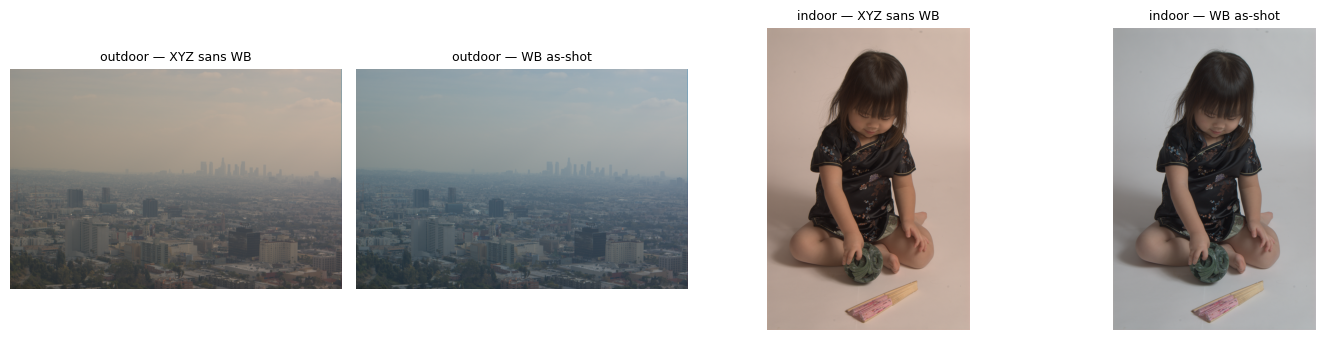

In [11]:
# Aperçu : le même RAW sans / avec balance des blancs (illuminant as-shot).
# Sans WB, la dominante de l'illuminant est visible (tungstène orangé en
# intérieur, bleu du ciel en extérieur) : c'est cette information que le
# papier tient à préserver au moment du mélange.
p_out = next(p for p, loc, _ in dng_files if loc == "outdoor")
p_in = next(p for p, loc, _ in dng_files if loc == "indoor")
xyz_out, il_out, saturated_out = read_raw_to_xyz(p_out)
xyz_in, il_in, saturated_in = read_raw_to_xyz(p_in)
show_row([xyz_to_display(xyz_out, white_balance=False), xyz_to_display(xyz_out, il_out),
          xyz_to_display(xyz_in, white_balance=False), xyz_to_display(xyz_in, il_in)],
         ["outdoor — XYZ sans WB", "outdoor — WB as-shot",
          "indoor — XYZ sans WB", "indoor — WB as-shot"], size=3.5)


(1520, 1007, 3)
(1000, 662, 3)


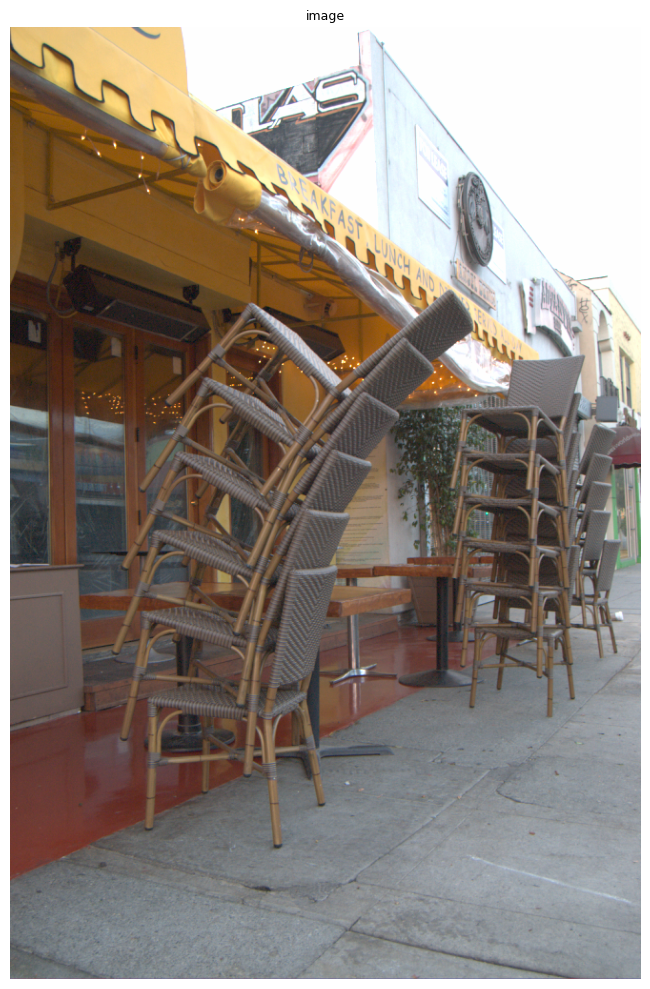

In [123]:
xyz_out, il_out, saturated_out = read_raw_to_xyz(dng_files[5][0])
print(xyz_out.shape)
h, w = xyz_out.shape[:2]
scale = MAX_SIDE / max(h, w)
if scale < 1:
    new = (round(w * scale), round(h * scale))
    xyz_out = cv2.resize(xyz_out, new,
                        interpolation=cv2.INTER_AREA)
print(xyz_out.shape)
show_row([ xyz_to_display(xyz_out, il_out),],
         ["image"], size=10)


images with sRAW, I'll throw them, cause the bayer filter makes no sense on it.
2/1000% of the files are sRAW

In [134]:
1440/np.sqrt(2)

np.float64(1018.2337649086284)

In [152]:
print(dng_files[128][0])

fivek_data/dng/a1370-kme_366.dng


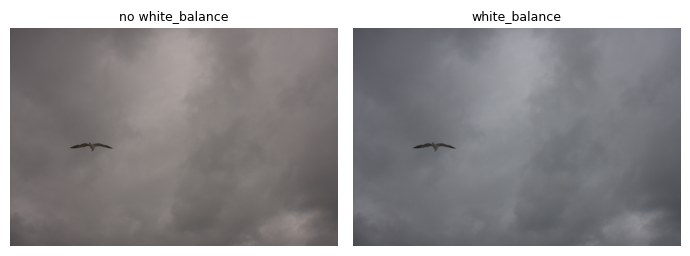

(1301, 1954, 3)


In [12]:
path_test = "fivek_data/dng/a1437-kme_124.dng"
path_test2 = "fivek_data/dng/a3131-KE_.dng"
path_test3 = dng_files[110][0]
xyz_in, il_in, saturated_in = read_raw_to_xyz(path_test3)
show_row([xyz_to_display(xyz_in, white_balance=False), xyz_to_display(xyz_in, il_in)],
         ["no white_balance","white_balance" ], size=3.5)
print(xyz_in.shape)

In [18]:
Y= xyz_in[..., 1]
Y[saturated_in].mean()

/tmp/ipykernel_707/2121406655.py:2: RuntimeWarning: Mean of empty slice.
  Y[saturated_in].mean()
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


np.float32(nan)

In [ ]:
def probe(path):
    with rawpy.imread(str(path)) as raw:
        v  = raw.raw_image_visible
        wl = float(raw.white_level)
        mx = int(v.max())
        n_top = int((v >= mx - 1).sum())
        return wl, mx, n_top / v.size, np.mean(raw.black_level_per_channel)

for i in (2,3,5,  20,25,30, 50, 110, 140, 200):
    p = dng_files[i][0]
    wl, mx, frac, black = probe(p)
    print(f"{i} wl={wl:7.0f} max={mx:6d} max/wl={mx/wl:.3f} "
          f"px_au_max={frac:.4%} black={black:.0f}")


2 wl=   3711 max=  3711 max/wl=1.000 px_au_max=0.2119% black=127
3 wl=   4095 max=  2284 max/wl=0.558 px_au_max=0.0000% black=0
5 wl=   4095 max=  4095 max/wl=1.000 px_au_max=7.2957% black=0
20 wl=   4000 max=  4095 max/wl=1.024 px_au_max=0.0108% black=248
25 wl=  16383 max= 16256 max/wl=0.992 px_au_max=1.0247% black=0
30 wl=   4095 max=  2013 max/wl=0.492 px_au_max=0.0000% black=0
50 wl=   4095 max=  4095 max/wl=1.000 px_au_max=0.0000% black=0
110 wl=  13600 max=  8188 max/wl=0.602 px_au_max=0.0000% black=1024
140 wl=   3692 max=  3692 max/wl=1.000 px_au_max=0.0015% black=128
200 wl=   4095 max=  4095 max/wl=1.000 px_au_max=0.0029% black=0


In [ ]:
with rawpy.imread(str(dng_files[0][0])) as raw:
    v = raw.raw_image_visible.ravel()
    wl, black = raw.white_level, np.mean(raw.black_level_per_channel)
    top = v[v > 0.6 * wl]
    print(f"white_level={wl}  max réel={v.max()}  black={black:.0f}")
    print(np.bincount(top - top.min())[-20:])   # un pic massif à droite = plateau


white_level=4095  max réel=2536  black=0
[0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0 0 1]


Un moment une matrice de couleur est pas inversible, on jète la photo, c'est une singularité du dataset
avec 500 échantillons du dataset j'ai 4 images où illum==None, je vais juste jeter ces singularités aussi.


In [46]:
def check(item,i):
    xyz, sat = item["xyz"], item["saturation"]
    assert xyz.shape[:2] == sat.shape, (xyz.shape, sat.shape)
    assert int(min(xyz.shape[:2])) * 0.5094 >=  PATCH, f"{i} trop petit pour un crop {PATCH}"
    assert np.isfinite(xyz).all(), f"NaN/inf dans xyz {i}"
    # assert xyz.min() >= 0, f"XYZ négatif non clippé, {i}"
    Y = xyz[..., 1]
    if sat.sum()>0:
        assert Y[sat].mean() > 3 * Y[~sat].mean(), f" {i} masque probablement mal orienté"


In [82]:
import cv2

# Charge tous les RAW en XYZ (réduits à MAX_SIDE pour tenir en mémoire)
def load_pool(files):
    pool = []
    for path, loc, cats in tqdm(files, desc="RAW -> XYZ"):
        xyz, illum, saturation = read_raw_to_xyz(path)
        # xyz = xyz.astype(np.float16)
        # if illum is None:
        #     illum = gray_world_white(xyz)
        # h, w = xyz.shape[:2]
        # scale = MAX_SIDE / max(h, w)
        # if scale < 1:
        #     new = (round(w * scale), round(h * scale))
        #     xyz = cv2.resize(xyz, new,
        #                      interpolation=cv2.INTER_AREA)
            
        #     # test resize saturation
        #     n_saturation = cv2.resize(saturation.astype(np.float32), new,
        #                     interpolation=cv2.INTER_AREA) > 0
        pool.append({"xyz": xyz.astype(np.float16), "e": read_exposure(path), "illum": illum,
                     "loc": loc, "cats": cats, "name": path.stem, "saturation" : saturation})
    return pool


pool = load_pool(dng_files[:])
print(f"{len(pool)} images, expositions e de "
      f"{min(p['e'] for p in pool):.2e} à {max(p['e'] for p in pool):.2e}")


RAW -> XYZ:   0%|          | 0/496 [00:00<?, ?it/s]

Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
496 images, expositions e de 9.77e-04 à 3.19e+02


In [14]:
def decode_raw_scaled(path, k,gamma=(1,1), **pp):
    with rawpy.imread(str(path)) as raw:
        black = float(np.mean(raw.black_level_per_channel[:4]))   # ±1 LSB, négligeable
        img = raw.raw_image
        img[:] = np.clip(black + (img.astype(np.float32) - black) * k,
                         0, raw.white_level).astype(np.uint16)
        params = dict(gamma=gamma, no_auto_bright=True, output_bps=16,
                      use_camera_wb=False, use_auto_wb=False, user_wb=[1.0] * 4,
                      output_color=rawpy.ColorSpace.raw, half_size=True,
                      adjust_maximum_thr=0.0)     # <- le point
        params.update(pp)
        cam = raw.postprocess(**params)
        M = np.linalg.inv(raw.rgb_xyz_matrix[:3, :3]).astype(np.float32)
    cam = cam.astype(np.float32) / 65535.0
    return np.einsum("ij,hwj->hwi", M, cam), cam


def test_linearite(path, gamma=(1,1), controle=None, **pp):
    """controle : exposant appliqué APRÈS décodage — valide la métrique elle-même."""
    xyz_1, cam_1 = decode_raw_scaled(path, 1.0, gamma=gamma, **pp)
    xyz_a, _     = decode_raw_scaled(path, 0.3, gamma=gamma, **pp)
    xyz_b, _     = decode_raw_scaled(path, 0.7, gamma, **pp)
    assert not np.allclose(xyz_a, xyz_1), "l'écriture dans raw_image n'a pas pris effet"

    f = (lambda x: np.clip(x, 0, None) ** controle) if controle else (lambda x: x)
    xyz_1, xyz_a, xyz_b = f(xyz_1), f(xyz_a), f(xyz_b)

    ok = (cam_1.min(-1) > 0.05) & (cam_1.max(-1) < 0.95)
    err = np.abs((xyz_a + xyz_b) - xyz_1)[ok] / np.abs(xyz_1[ok]).clip(1e-6)
    return np.median(err), np.percentile(err, 99)


for p, *_ in dng_files[:5]:
    with rawpy.imread(str(p)) as raw:
        r = raw.raw_image_visible.max() / raw.white_level

    ok_med,  _ = test_linearite(p)
    bug_med, _ = test_linearite(p, adjust_maximum_thr=0.75)
    ctl_med, _ = test_linearite(p, controle=0.45)
    print(f"{p.stem[:28]:30s} corrigé {ok_med:7.3%} | thr=0.75 {bug_med:7.2%} | contrôle {ctl_med:6.1%}, r={r}")


a0419-DSC_0008                 corrigé  0.101% | thr=0.75   0.10% | contrôle  43.3%, r=0.6192918192918193
a4211-Duggan_090305_5296       corrigé  0.079% | thr=0.75   0.08% | contrôle  43.3%, r=1.0
a2242-JI2E5686                 corrigé  0.212% | thr=0.75   0.21% | contrôle  43.2%, r=1.0
a0050-_DSC0006                 corrigé  0.160% | thr=0.75   0.16% | contrôle  43.2%, r=0.5577533577533578
a0888-_DSC0011                 corrigé  0.114% | thr=0.75  23.91% | contrôle  43.3%, r=0.7619047619047619


In [142]:
for p, *_ in dng_files[110:300]:
    with rawpy.imread(str(p)) as raw:
        blacks = np.array(raw.black_level_per_channel[:4], float)
        white  = float(raw.white_level)
        n_sat  = int((raw.raw_image_visible >= white).sum())
        cam = raw.postprocess(
            gamma=(1, 1), no_auto_bright=True, adjust_maximum_thr=0.0,
            output_bps=16, use_camera_wb=False, use_auto_wb=False, user_wb=[1.0] * 4,
            output_color=rawpy.ColorSpace.raw, half_size=True)
    if n_sat>0 and cam.max()<65530:
        print(f"niveaux      : noir {blacks.mean():.1f}   blanc {white:.0f}")
        print(f"photosites au white_level dans le RAW : {n_sat}")
        print(f"max en sortie                         : {cam.max()} / 65535")


niveaux      : noir 127.8   blanc 3692
photosites au white_level dans le RAW : 2
max en sortie                         : 64946 / 65535
niveaux      : noir 127.5   blanc 3711
photosites au white_level dans le RAW : 9
max en sortie                         : 65516 / 65535
niveaux      : noir 127.5   blanc 4095
photosites au white_level dans le RAW : 98
max en sortie                         : 65526 / 65535
niveaux      : noir 257.0   blanc 4057
photosites au white_level dans le RAW : 10
max en sortie                         : 65120 / 65535
niveaux      : noir 130.0   blanc 4000
photosites au white_level dans le RAW : 133
max en sortie                         : 65509 / 65535
niveaux      : noir 0.0   blanc 4095
photosites au white_level dans le RAW : 1
max en sortie                         : 55484 / 65535
niveaux      : noir 127.5   blanc 3692
photosites au white_level dans le RAW : 1684
max en sortie                         : 65525 / 65535
niveaux      : noir 0.0   blanc 3880
photosites au

## 3. Simulation de reflets (Func. 1 du papier)

Pour une paire d'images XYZ `(i, j)` :

1. `j` est coupée en deux moitiés disjointes → source du **reflet** `r` et du
   **contexte** `c` (Sec. 3.3 : la photo contextuelle regarde la scène
   reflétée mais ne partage pas exactement son contenu — les moitiés
   disjointes modélisent ça gratuitement) ;
2. crop aléatoire de `i` → **transmission** `t` ;
3. **dé-exposition** par `e = s·g/n²` : les pixels redeviennent proportionnels
   à la luminance de la scène ;
4. simulation **géométrique** (Sec. 3.2 / B) : on échantillonne une **caméra**
   (FOV 40–90°, ~65° en moyenne comme le papier) et une **vitre inclinée**,
   puis on en dérive physiquement :
   - l'angle d'incidence *par pixel* → **réflectance de Fresnel exacte**
     (verre n = 1.52, deux interfaces) — plus forte côté rasant ;
   - une **homographie de rotation** `H = K·R·K⁻¹` : le reflet est vu sous un
     autre angle que la photo qui lui sert de source ;
   - un **défocus optique** : cercle de confusion calculé avec mise au point
     sur le sujet transmis, la scène reflétée étant virtuellement à
     `d_vitre + d_scène` — la plupart des reflets restent nets, comme le
     note le papier ;
   - un **fantôme** de double réflexion : les deux faces de la vitre
     réfléchissent presque autant (~4 % chacune), décalées de
     `2·h·tan(θ_t)·cos(θ_i)` (épaisseur du verre h, projeté en pixels) ;
   - la transmission est atténuée par `(1 − R)` (la vitre absorbe une part
     de la lumière transmise) ;
5. mélange **additif** `m = t + r` ;
6. **ré-exposition** : le pixel moyen vise `τ` (fonction de capture `C`) ;
7. **balance des blancs partagée** : le photographe règle pour son sujet →
   on balance sur l'**illuminant as-shot de la transmission** (CAT Bradford
   → D50). Le reflet garde donc sa dominante — bleu d'un extérieur au-dessus
   d'un intérieur tungstène, jaune d'un intérieur sur un extérieur — ce sont
   exactement les priors de couleur discutés dans le papier (Fig. 3a) ;
8. conversion **XYZ(D50) → sRGB linéaire**.

**Écart principal au papier** (`NORMALIZE_POWER = True`) : eux mélangent des
paires purement physiques et *cherchent* les mélanges utiles parmi 10⁸
candidats. Avec ~16 images, les ratios d'exposition FiveK (plein soleil vs
intérieur sombre) donnent presque toujours un reflet invisible ou écrasant.
On normalise donc chaque composante à luminance moyenne 1 et on échantillonne
un ratio de puissance reflet/transmission plausible (log-uniforme ~[0.3, 5],
encore atténué par Fresnel). Mets le flag à `False` pour la version purement
physique du papier (taux d'acceptation très faible).


| Format       | Largeur | Flou médian | Nets (<1 px) | Flous (>3 px) |
|--------------|---------|-------------|--------------|---------------|
| Téléphone    | 6,2 mm  | 0,08 px     | 99 %         | 0 %           |
| 1 pouce      | 13,2 mm | 0,16 px     | 93 %         | 0 %           |
| Micro 4/3    | 17,3 mm | 0,21 px     | 89 %         | 1 %           |
| APS-C        | 23,6 mm | 0,29 px     | 83 %         | 3 %           |
| Plein format | 36 mm   | 0,45 px     | 72 %         | 6 %           |


In [ ]:
GLASS_IOR = 1.52      # indice de réfraction d'un verre courant
# SENSOR_W = 0.036      # capteur plein format (m) (format donnant le + de flou) capteur plein format 36x24 mm
# cela explique pourquoi un téléphone est très net (taille du capteur petit cf formule du defocus blur)
SENSOR_full_min = 0.024
SENSOR_W = SENSOR_full_min
SENSOR_APS_C_min  = 0.0157
# on peut imaginer simuler plusieurs capteurs, le main capteur de mon dataset c'est APS-C, 
# mais les capteurs de mon dataset ne sont pas forcément ce que je veux simuler
# on prend le min parce qu'on veut faire un carré, maintenant si je veux des images 3/2 je garde SENSOR_W=0.036 m
def _fresnel_single(cos_i, n=GLASS_IOR):
    """Fresnel non polarisé, une interface air->verre."""
    cos_i = np.clip(cos_i, 1e-6, 1.0)
    sin_t = np.sqrt(np.clip(1 - cos_i ** 2, 0, 1)) / n
    cos_t = np.sqrt(np.clip(1 - sin_t ** 2, 0, 1))
    rs = ((cos_i - n * cos_t) / (cos_i + n * cos_t)) ** 2
    rp = ((n * cos_i - cos_t) / (n * cos_i + cos_t)) ** 2
    return 0.5 * (rs + rp)

def fresnel_angle(theta_i, n=GLASS_IOR):
    """
    Formule de Fresnel arrangée (celle du papier), même résultats que _fresnel_single
    """
    theta_i = theta_i * np.pi/180
    theta_ip = np.arcsin(np.sin(theta_i)/n)
    sum = theta_i + theta_ip
    substrat = theta_i - theta_ip
    rs = (np.sin(substrat)/np.sin(sum))**2
    rp = (np.tan(substrat)/np.tan(sum))**2
    return (rs + rp) * 0.5

def fresnel_reflectance(cos_i, n=GLASS_IOR):
    """Vitre à deux interfaces (réflexions internes multiples) : 2R/(1+R).
       Somme géométrique
    """
    R = _fresnel_single(cos_i, n)
    return 2 * R / (1 + R) 


def sample_scene(rng, size):
    """Tire une caméra + une vitre + des distances, et en dérive tous les
    paramètres géométriques du reflet (Sec. B, simplifié : une vitre plane).
    
    explanation:
    theta0: angle de la vitre (pour un pare brise, on a une vitre très inclinée)
    phi: 
    FoV = Field of Vision
    
    """
    # caméra : FOV 40-90° (moyenne ~65° comme le papier, Sec. B.2)
    fov = float(rng.uniform(40, 90)) #à priori ça c'est bien
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    # rayons par pixel + normale de la vitre inclinée de theta0
    ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
    d = np.stack([xs, ys, np.full_like(xs, f_px)], -1)
    d /= np.linalg.norm(d, axis=-1, keepdims=True)

    # paramètres de la vitre
    half_diag = np.arctan(np.sqrt(2) * np.tan(np.radians(fov) / 2))
    theta0_max = np.radians(83.0) - half_diag        # theta_i <= 75 deg partout
    theta0 = float(rng.uniform(0, theta0_max))
    phi = float(rng.uniform(0, 2 * np.pi)) 

    # on passe en coordonnées cartésiennes pour être fidèle par rapport à ys, xs
    # par construction nrm est de norm 1 https://fr.wikipedia.org/wiki/Coordonn%C3%A9es_sph%C3%A9riques
    nrm = np.array([np.sin(theta0) * np.cos(phi),
                    np.sin(theta0) * np.sin(phi),
                    np.cos(theta0)], np.float32)
    cos_i = np.abs(d @ nrm)                      # angle d'incidence par pixel
    
    # défocus : mise au point sur le sujet transmis, la scène reflétée est
    # virtuellement à d_glass + distance derrière la vitre (miroir)
    f_m = f_px / size * SENSOR_W                 # focale en mètres
    N = float(rng.uniform(1.8, 8.0))             # ouverture
    d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))          # sujet : 0.5-8 m
    # 0.3 pour ne pas coller la vitre au verre et au plus 3 metres car sinon la vitre n'est pas le
    # principal, mais au max ça vaut d_focus parce que la vitre est entre moi et ce que je photographie
    d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))  # 1-50 m derrière
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = coc / SENSOR_W * size           # cercle de confusion en pixels

    # adding this for later (modelise double pane)
    # double_pane = rng.random() < 0.5              # 50% des fenêtres réelles
    # path = h_glass * tan_t                        # verre : angle réfracté
    # if double_pane:
    #     gap = float(rng.uniform(0.006, 0.020))    # lame d'air (m)
    #     tan_i = sin_i / np.maximum(cos_i, 1e-8)
    #     path = path + gap * tan_i                 # air : angle PLEIN, pas de réfraction
    # ghost_px = (f_px * 2 * path * cos_i / d_glass).astype(np.float32)

    # # le rayon dominant traverse 4 interfaces au lieu de 2 en double vitrage
    # R1 = _fresnel_single(cos_i).astype(np.float32)
    # ghost_w = (1.0 - R1) ** (4 if double_pane else 2)


    # ghost : décalage latéral de la réflexion sur la 2e face du verre
    h_glass = float(rng.uniform(0.003, 0.015))   # épaisseur du verre (m) (0.003, 0.012) pourquoi 0.0012?

    sin_i = np.sqrt(np.clip((1 - cos_i**2), 0 , None)) # on se limite à [0,pi/2] ? 
    sin_t = sin_i / GLASS_IOR
    tan_t = sin_t / np.sqrt(1 - sin_t ** 2)
    ghost_px = f_px * 2 * h_glass * tan_t * cos_i / d_glass

    # direction du décalage, PAR PIXEL : projection du rayon sur le plan de la vitre
    tang = d - (d @ nrm)[..., None] * nrm
    tang /= np.maximum(np.linalg.norm(tang, axis=-1, keepdims=True), 1e-8) # on divise pas par 0 ce qui est le cas dans quand la direction
    # des pixels est parallèle à la normale
    ghost_dir = tang[..., :2].astype(np.float32)          # trace dans le plan image
    ghost_dir /= np.maximum(np.linalg.norm(ghost_dir, axis=-1, keepdims=True), 1e-8)
    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": fresnel_reflectance(cos_i)[..., None].astype(np.float32),
            "R1_map": _fresnel_single(cos_i).astype(np.float32),
            "defocus_px": float(defocus_px), "ghost_px": (ghost_px.astype(np.float32)), "ghost_dir" : ghost_dir}


def det_params(fov="", theta0="", phi="", N="", d_focus="", d_glass="", d_refl="", h_glass=""):
    """ Choices:
    fov: 40-90 ? 
    theta0: 0-55° ?
    phi: 0-2pi ?
    N: 1.8-8 ?
    d_focus: 0.5-8 m ?
    d_glass: 0.3-3 m ?
    d_refl: 1-50 m ?
    h_glass: 0.003-0.015 m ?
    """
    return {"fov": fov, "theta0": theta0, "phi": phi,
            "aperture": N, "d_focus": d_focus,
            "d_glass": d_glass, "d_refl": d_refl,
            "h_glass": h_glass}



def deterministic_scene(rng, size, params):
    """Like sample_scene but with deterministic parameters to test."""
    if params['fov']:
        fov = params["fov"]
    else:
        fov = float(rng.uniform(40, 90)) 
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
    d = np.stack([xs, ys, np.full_like(xs, f_px)], -1)
    d /= np.linalg.norm(d, axis=-1, keepdims=True)

    if params["theta0"]:
        theta0 = params['theta0']
    else:
        half_diag = np.arctan(np.sqrt(2) * np.tan(np.radians(fov) / 2))
        theta0_max = np.radians(83.0) - half_diag        # theta_i <= 75 deg partout
        theta0 = float(rng.uniform(0, theta0_max))

    if params["phi"]:
        phi = params['phi']
    else:
        phi = float(rng.uniform(0, 2 * np.pi)) 

    nrm = np.array([np.sin(theta0) * np.cos(phi),
                    np.sin(theta0) * np.sin(phi),
                    np.cos(theta0)], np.float32)
    cos_i = np.abs(d @ nrm)                     

    f_m = f_px / size * SENSOR_W                

    if params["aperture"]:
        N = params['aperture']
    else:  
        N = float(rng.uniform(1.8, 8.0))   
    if params["d_focus"]:
        d_focus = params['d_focus']
    else:         
        d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))        
    if params["d_glass"]:
        d_glass = params['d_glass']
    else:
        d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    if params["d_refl"]:
        d_refl = params['d_refl'] + d_glass
    else:
        d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))  
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = coc / SENSOR_W * size       

    if params["h_glass"]:
        h_glass = params['h_glass']
    else:
        h_glass = float(rng.uniform(0.003, 0.015))   

    sin_i = np.sqrt(np.clip((1 - cos_i**2), 0 , None)) # on se limite à [0,pi/2] ? 
    sin_t = sin_i / GLASS_IOR
    tan_t = sin_t / np.sqrt(1 - sin_t ** 2)
    ghost_px = f_px * 2 * h_glass * tan_t * cos_i / d_glass

    # direction du décalage, PAR PIXEL : projection du rayon sur le plan de la vitre
    tang = d - (d @ nrm)[..., None] * nrm
    tang /= np.maximum(np.linalg.norm(tang, axis=-1, keepdims=True), 1e-8) # on divise pas par 0 ce qui est le cas dans quand la direction
    # des pixels est parallèle à la normale
    ghost_dir = tang[..., :2].astype(np.float32)          # trace dans le plan image
    ghost_dir /= np.maximum(np.linalg.norm(ghost_dir, axis=-1, keepdims=True), 1e-8)
    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": fresnel_reflectance(cos_i)[..., None].astype(np.float32),
            "R1_map": _fresnel_single(cos_i).astype(np.float32),
            "defocus_px": float(defocus_px), "ghost_px": (ghost_px.astype(np.float32)), "ghost_dir" : ghost_dir}

def random_crop(img, size, sat, rng):
    h, w = img.shape[:2]
    c = int(min(h, w) * rng.uniform(0.5094, 1.0))
    y = int(rng.integers(0, h - c + 1))
    x = int(rng.integers(0, w - c + 1))
    crop = img[y:y + c, x:x + c]
    if c<= size:
        print("problem c <= size interpolation random crop")
    interp = cv2.INTER_AREA if c >= size else cv2.INTER_LINEAR
    return cv2.resize(crop, (size, size), interpolation=interp), float(sat[y:y + c, x:x + c].mean()) #, (x,y,c)

def random_crop(img, size, sat, rng):
    h, w = img.shape[:2]
    C = int(min(h, w) * rng.uniform(0.4, 1.0))
    C = max(C, size)                                  # plancher : jamais d'upscale
    y = int(rng.integers(0, h - C + 1))
    x = int(rng.integers(0, w - C + 1))
    crop = np.asarray(img[y:y+C, x:x+C], np.float32)    # slice : gratuit
    out = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)   # seul resize
    return out, float(sat[y:y+C, x:x+C].mean())

# def split_reflection_context(img, rng):
#     """Moitiés disjointes (Sec. 3.3) : l'une donne r, l'autre c."""
#     h, w = img.shape[:2]
#     if rng.random() < 0.5:
#         halves = img[:, : w // 2], img[:, w // 2:]
#     else:
#         halves = img[: h // 2], img[h // 2:]
#     i = int(rng.random() < 0.5)
#     return halves[i], halves[1 - i]

def disk_kernel(radius):
    y, x = np.mgrid[-radius:radius + 1, -radius:radius + 1]
    k = ((x ** 2 + y ** 2) <= radius ** 2).astype(np.float32)
    return k / k.sum()

def defocus(img, radius):
    """Flou de défocus : noyau disque (bokeh), pas gaussien."""
    if radius < 1:
        return img
    return cv2.filter2D(img, -1, disk_kernel(int(radius)))

def double_reflection(img, scene, rng):
    """Fantôme : la 2e réflexion sort décalée d'une quantité qui varie PAR PIXEL —
    nulle là où le rayon est normal à la vitre, croissante ensuite."""
    shift = scene["ghost_px"]                        # carte (h, w)
    if float(shift.max()) < 0.15:                    # tout le champ est négligeable
        return img
    h, w = img.shape[:2]
    ys, xs = np.mgrid[0:h, 0:w].astype(np.float32)
    dxy = scene["ghost_dir"]                         # carte (h, w, 2)
    map_x = (xs - dxy[..., 0] * shift).astype(np.float32)
    map_y = (ys - dxy[..., 1] * shift).astype(np.float32)
    ghost = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REFLECT)
    a = ((1.0 - scene["R1_map"]) ** 2)[..., None]    # poids aussi par pixel
    return (img + a * ghost) / (1.0 + a), ghost

## TESTS sample scene reflection



### parameters to test double reflection results on imgs

In [17]:
# ghost_px = f_px × 2h × [tan(θ_t)·cos(θ₀)] / d_glass

# realist but maximum-> ghost of 10,6 px
realistic_dbr = det_params(fov=40, theta0=np.radians(49), phi=0.0,
                    N=2.8, d_focus=1.0, d_glass=0.3, h_glass=0.012)

# thick glass, phone next to the glass -> 26 px
hard_dbr = det_params(fov=40, theta0=np.radians(49), phi=0.0,
                    N=2.8, d_focus=1.0, d_glass=0.2, h_glass=0.020)

# exagerated double reflection
exagerated_dbr = det_params(fov=20, theta0=np.radians(49), phi=0.0,
                    N=2.8, d_focus=1.0, d_glass=0.2, h_glass=0.020)

In double reflection using borderMode=cv2.BORDER_REFLECT will have a non negligeable effect on huge double reflection and shift (see the ghost of exagerated_dbr )   
(image_raw_exp\border_effects_ghost_300_410_hard_dbr.png)

In [62]:
pool_i = pool[i]
xyz_i, illum_i, sat_i = pool_i["xyz"], pool_i["illum"], pool_i["saturation"]
sat_i.sum()

np.int64(350)

In [65]:
FRAC_MIN, PATCH = 0.5094, 512

def check_item(it):
    """Invariants par image. Retourne la liste des problèmes détectés."""
    p, xyz, sat = [], it["xyz"], it["saturation"]
    h, w = xyz.shape[:2]

    # --- formes ---
    if xyz.ndim != 3 or xyz.shape[2] != 3:  p.append(f"shape {xyz.shape}")
    if sat.shape != (h, w):                 p.append(f"masque {sat.shape} != image {(h,w)}")
    if min(h, w) < PATCH:                   p.append(f"trop petit : {min(h,w)} < {PATCH}")
    elif min(h, w) < PATCH / FRAC_MIN:      p.append(f"échelle de crop tronquée ({min(h,w)})")

    # --- validité numérique ---
    if not np.isfinite(xyz).all():          p.append("NaN/inf dans xyz")
    if xyz.min() < 0:                       p.append(f"XYZ négatif ({xyz.min():.3g})")
    Y = xyz[..., 1]
    if Y.std() < 1e-6:                      p.append("image constante (décodage raté ?)")

    # --- orientation du masque : rang, pas ratio ---
    if sat.any():
        frac = float((Y[sat] >= np.quantile(Y, 0.99)).mean())
        if frac < 0.5:                      p.append(f"masque mal orienté ? top1% = {frac:.2f}")
    if sat.mean() > 0.30:                   p.append(f"saturation {sat.mean():.1%} (seuil trop bas ?)")

    # --- illuminant : chromaticité sur le locus plausible (2000K-15000K) ---
    il = it["illum"]
    if il is None or not np.isfinite(il).all():
        p.append("illuminant invalide")
    else:
        s = il.sum(); x, y = il[0]/s, il[1]/s
        if not (0.24 < x < 0.56 and 0.24 < y < 0.44):
            p.append(f"illuminant aberrant xy=({x:.3f}, {y:.3f})")

    if not np.isfinite(it["e"]) or it["e"] <= 0:
        p.append(f"exposition e={it['e']}")
    return p


def check_pool(pool):
    print(f"=== {len(pool)} images ===")
    n_bad = 0
    for it in pool:
        pb = check_item(it)
        if pb:
            n_bad += 1
            print(f"  {it['name']:26s} " + " | ".join(pb))
    print(f"  -> {n_bad} images signalées\n")

    # 1) la saturation est-elle détectée du tout ?
    sat = np.array([it["saturation"].mean() for it in pool])
    print(f"saturation : médiane {np.median(sat):.3%} | max {sat.max():.2%} | "
          f"images à 0 : {(sat == 0).sum()}/{len(pool)}")
    if (sat == 0).mean() > 0.9:
        print("  !! quasi aucune saturation -> white_level probablement surestimé")
    if np.median(sat) > 0.10:
        print("  !! saturation médiane énorme -> seuil ou black_level suspect")

    # 2) échelle après dé-exposition : c'est ce qui rend m = t + r cohérent
    key = np.array([np.exp(np.log(np.clip(it["xyz"][::8, ::8, 1] / it["e"],
                                          1e-8, None)).mean()) for it in pool])
    med = np.median(key)
    print(f"\nluminance dé-exposée : médiane {med:.3g}, "
          f"p1 {np.percentile(key,1):.3g}, p99 {np.percentile(key,99):.3g}")
    out = [(it["name"], f"{k/med:.0f}x") for it, k in zip(pool, key)
           if k < med/100 or k > med*100]
    if out:
        print(f"  {len(out)} outliers (EXIF douteux) :", out[:8])

    # 3) diversité des illuminants : sinon pair_score ne discrimine rien
    xy = np.array([[it["illum"][0], it["illum"][1]] / it["illum"].sum() for it in pool])
    print(f"\nilluminants : x {xy[:,0].min():.3f}-{xy[:,0].max():.3f}, "
          f"écart-type {xy[:,0].std():.4f}")


In [66]:
check_pool(pool)

=== 10 images ===
  a1097-IMG_0984             XYZ négatif (-0.00212)


/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:173: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:107: RuntimeWarning: overflow encountered in cast
  get_virtual_index=lambda n, quantiles: (n - 1) * quantiles,
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4717: RuntimeWarning: overflow encountered in cast
  indexes_above_bounds = virtual_indexes >= valid_values_count - 1
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4622: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4623: RuntimeWarning: invalid value encountered in scalar multiply
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


  a1257-_I2E6481             masque mal orienté ? top1% = 0.00 | saturation 39.7% (seuil trop bas ?)
  a4231-Duggan_080326_5786   XYZ négatif (-0.00078) | masque mal orienté ? top1% = 0.00
  a1766-jmac_DSC1042         masque mal orienté ? top1% = 0.00
  a0393-_DSC0040             XYZ négatif (-0.00166)
  a2134-IMG_0042             XYZ négatif (-0.00366) | masque mal orienté ? top1% = 0.00
  a2111-_DSC5607             XYZ négatif (-0.0304) | masque mal orienté ? top1% = 0.00
  a3823-kme_459              XYZ négatif (-0.0097) | masque mal orienté ? top1% = 0.00
  a1047-IMG_2420             XYZ négatif (-0.00864) | masque mal orienté ? top1% = 0.00
  a1034-_I2E8160             XYZ négatif (-0.00329)
  -> 10 images signalées

saturation : médiane 0.068% | max 39.67% | images à 0 : 3/10

luminance dé-exposée : médiane 3.68, p1 0, p99 19
  2 outliers (EXIF douteux) : [('a2134-IMG_0042', '0x'), ('a1034-_I2E8160', '0x')]

illuminants : x 0.323-0.368, écart-type 0.0129


/tmp/ipykernel_707/3040671318.py:60: RuntimeWarning: divide by zero encountered in log
  key = np.array([np.exp(np.log(np.clip(it["xyz"][::8, ::8, 1] / it["e"],


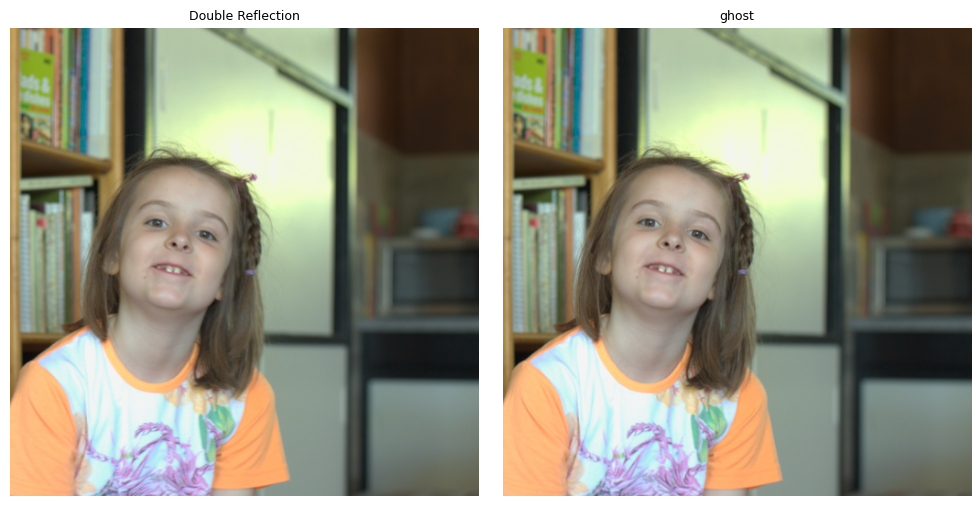

(None,)

In [244]:
i = 280
pool_i = pool[i]
xyz_i, illum_i, sat_i = pool_i["xyz"], pool_i["illum"], pool_i["saturation"]
xyz_i, sat_i = random_crop(xyz_i, PATCH, sat_i, rng)
params = det_params(fov=80, theta0=np.radians(49), phi=np.pi/4, N=2.8, d_focus=1.0, d_glass=3, d_refl=5.0, h_glass=0.02)

# params = realistic_dbr
scene_i = deterministic_scene(rng, PATCH, params)
xyz_i, ghost = double_reflection(xyz_i, scene_i, rng)
show_row([xyz_to_display(xyz_i, illum_i), xyz_to_display(ghost, illum_i)] ,["Double Reflection", "ghost"], size=5),

In [94]:
SAT_TOL = 0.02
def compute_exposure(m, t, r, sat_t, sat_r, M):
    """
    S1 function
    We're USING TAU = srgb_decode((0.4)) = 0.1329
    have to delete context
    """
    # print(f"sat_t, sat_r = {sat_t, sat_r}")
    m_s, t_s, r_s = apply_matrix(m, M), apply_matrix(t, M), apply_matrix(r, M)
    if sat_t <= SAT_TOL and sat_r<= SAT_TOL:
      mu = max(m_s.mean(),1e-8)
      e = TAU / mu
    else:
      e = 1.0 / (min(float((t_s).max()), float((r_s).max())))
    # print(f"e={e}")
    # print(f"t_max/t_mean = {t_s.max()/t_s.mean():.0f}   r_max/r_mean = {r_s.max()/r_s.mean():.0f}")
    
    return m_s * e, t_s * e, r_s * e 

In [ ]:
def simulate_example(src_t, src_r, rng, patch=None, tau=None, params={}, deterministic=False):
    """Func. 1 du papier. src_t, src_r = entrées du pool (xyz, e, illum...).
    Retourne (m, t, r, c) en sRGB linéaire."""
    patch = patch or PATCH
    tau = tau or TAU

    # 1-2) découpes : t depuis l'image i ; (r, c) = moitiés disjointes de j
    sat_t, sat_r = src_t["saturation"], src_r["saturation"]
    t, frac_t = random_crop(src_t["xyz"], patch, sat_t, rng)
    r, frac_r= random_crop(src_r["xyz"], patch, sat_r, rng)
    
    M = XYZ_D50_TO_SRGB @ cat_matrix(src_t["illum"])
    # 3) dé-exposition : pixels proportionnels à la luminance de scène
    t, r = t / src_t["e"], r / src_r["e"]
    # 4) simulation géométrique : caméra + vitre échantillonnées (Sec. B)
    if deterministic:
        assert params, "deterministic=True requires params"
        scene = deterministic_scene(rng, patch, params)
    else:
        scene = sample_scene(rng, patch)
    # on retourne l'image pour l'effet miroir quand on prend une photo
    if rng.random() < 0.5:
        r = r[:, ::-1].copy()                    # miroir (c reste une vue directe)
    r = defocus(r, int(round(min(scene["defocus_px"], 12))))
    r = double_reflection(r, scene, rng)[0]         # fantôme des deux faces
    r = r * scene["R_map"]                       # Fresnel par pixel
    t = t * (1.0 - scene["R_map"])               # la vitre atténue aussi t
    # 5) mélange additif : la lumière s'additionne sur le capteur
    m = t + r # it is like alpha * R + (1-alpha)*T 
    # 6) ré-exposition (Func. S1 simplifié)
    m, t, r= compute_exposure(m, t, r, frac_t, frac_r, M)
    frac = (m > 2).sum()
    m, t, r = (np.clip(x, 0.0, 1.0) for x in (m, t, r))
    return {"m": m, "t": t, "r": r, "frac" : frac}

In [235]:
sat_pool = []
for i in range(len(pool)):
    if pool[i]["saturation"].sum()>=100:
        sat_pool.append(i)


In [228]:
import cv2
import numpy as np


def _ssim_map(x, y, data_range, sigma):
    """Per-pixel SSIM map for one channel (Wang et al., 2004, eq. 13)."""
    ksize = int(3.5 * sigma + 0.5) * 2 + 1          # 11x11 for sigma = 1.5

    def blur(im):                                    # local Gaussian average
        return cv2.GaussianBlur(im, (ksize, ksize), sigma,
                                borderType=cv2.BORDER_REFLECT)

    C1, C2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    ux, uy = blur(x), blur(y)                        # local means
    vx = blur(x * x) - ux * ux                       # local variances
    vy = blur(y * y) - uy * uy
    vxy = blur(x * y) - ux * uy                      # local covariance
    return (((2 * ux * uy + C1) * (2 * vxy + C2)) /
            ((ux * ux + uy * uy + C1) * (vx + vy + C2)))

def ssim_fast(m, t, data_range=1.0):
    """skimage default (uniform 7x7 + sample covariance), 4.5x faster."""
    C1, C2 = 1e-4, 9e-4                             
    cn = 49 / 48                                     
    f = lambda im: cv2.boxFilter(im, -1, (7, 7), normalize=True,
                                 borderType=cv2.BORDER_REFLECT)
    ux, uy = f(m), f(t)
    vx  = cn * (f(m * m) - ux * ux)
    vy  = cn * (f(t * t) - uy * uy)
    vxy = cn * (f(m * t) - ux * uy)
    S = ((2 * ux * uy + C1) * (2 * vxy + C2)) / ((ux * ux + uy * uy + C1) * (vx + vy + C2))

    w = np.array([m[..., k].mean() for k in range(3)], np.float64)   # D.1 weights
    w /= max(w.sum(), 1e-8)
    S = (S[3:-3, 3:-3] * w).sum(axis=-1)           
    return float(S.mean()), float(S.std())


def ssim2(a, b, data_range=1.0, sigma=1.5, full=False):
    """Structural similarity between two images of identical shape.

    a, b        : (H, W) or (H, W, C) arrays; channels are averaged.
    data_range  : peak-to-peak value of the data (1.0 for floats, 255 for uint8).
    full        : also return the per-pixel SSIM map.
    """
    a = np.asarray(a, np.float64)
    b = np.asarray(b, np.float64)
    if a.shape != b.shape:
        raise ValueError(f"shape mismatch: {a.shape} vs {b.shape}")

    single = a.ndim == 2
    if single:
        a, b = a[..., None], b[..., None]

    S = np.stack([_ssim_map(a[..., k], b[..., k], data_range, sigma)
                  for k in range(a.shape[-1])], axis=-1)

    pad = int(3.5 * sigma + 0.5)                     # drop the padded border
    score = float(S[pad:-pad, pad:-pad].mean())
    if not full:
        return score
    return score, (S[..., 0] if single else S)


In [88]:
def reference_mean_distribution(pool):
    """D.1 reference: mean pixel value over normally-rendered source RAWs."""
    means = []
    for p in pool:
        M = XYZ_D50_TO_SRGB @ cat_matrix(p["illum"])
        lin = np.clip(apply_matrix(np.asarray(p["xyz"], np.float32), M), 0.0, 1.0)
        means.append(float(lin.mean()))
    return float(np.mean(means)), float(np.std(means))

MU, SD = reference_mean_distribution(pool)
print(f"reference: mu={MU:.4f}  sigma={SD:.4f}  -> band [{MU-2*SD:.4f}, {MU+2*SD:.4f}]")
print(f"tau = {TAU:.4f}   ({'coherent' if abs(MU-TAU) < 2*SD else 'ECART -- a investiguer'})")


reference: mu=0.1444  sigma=0.0946  -> band [-0.0448, 0.3335]
tau = 0.1329   (coherent)


In [135]:
from skimage.metrics import structural_similarity as ssim
m, t = sim["m"], sim["t"]
ssim(m, t, data_range=1, channel_axis=-1), ssim_fast(m , t, 1)

(np.float32(0.77034813), (0.7726656004378746, 0.20791504481145978))

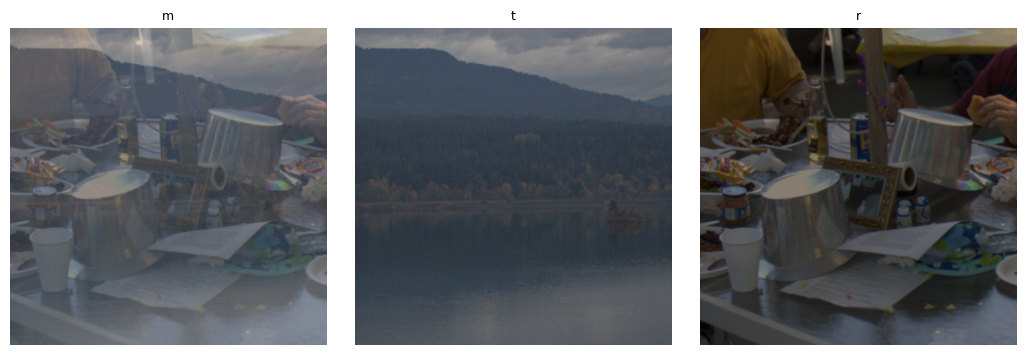

True

In [ ]:
src_t, src_r = pool[3], pool[18]
sim = simulate_example(src_t, src_r, rng=np.random.default_rng(58), deterministic=False)
# print(ssim(sim["m"], sim["t"], channel_axis=-1, data_range=sim["t"].max()- sim["t"].min()))
show_row([sim["m"], sim["t"], sim["r"]], ["m", "t", "r"], size=3.5)

In [ ]:
c = 0
means, xyz_p = [], []
for i in range(len(pool)):
    mean_i = pool[i]['xyz'].mean()
    if mean_i>0.4:
        means.append(mean_i)
        xyz_p.append(i)

[np.float16(0.4504), np.float16(0.414), np.float16(0.57), np.float16(0.4983), np.float16(0.453), np.float16(0.4326), np.float16(0.4087), np.float16(0.5254), np.float16(0.4749), np.float16(0.497), np.float16(0.4902), np.float16(0.6025)]


In [154]:
CULL_SIZE = 256
def is_useful(ex):
    """Recherche du papier (Sec. D) réduite à quelques heuristiques :
    bien exposé, reflet visible mais pas destructeur, structures présentes."""
    m, t, r = ex["m"], ex["t"], ex["r"]
    # if 0.35 >=m.mean()>= 0.04:
    #     return False
    m = cv2.resize(m, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    t = cv2.resize(t, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    r = cv2.resize(r, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    ssim_m_t, std_m_t = ssim_fast(m,t)
    if ssim_m_t > 0.94 or ssim_m_t <0.4:
        return False
    
    if std_m_t < 0.05:
        return False
    if m.mean()>=0.7:
        return False
    Ym = luminance(m).mean()
    if not 0.04 < Ym < 0.6:                       # exposition correcte
        return False
    vis = luminance(r).mean() / (Ym + 1e-8)
    if not 0.04 < vis < 0.6:                      # visibilité du reflet
        return False
    if luminance(t).std() < 0.015:          # transmission plate/noyée
        return False
    if luminance(r).std() < 0.008:          # reflet sans structure
        return False
    return True


## 3 bis. Choisir des paires réalistes (Sec. D du papier)

Le papier n'apparie pas les images au hasard : le verre est placé avec
intention dans le monde (vitrines, musées, voitures...), ce qui crée des
priors. Ils les obtiennent en cherchant parmi 10⁸ mélanges physiques ; ici on
les encode dans un **score de paire** à partir des catégories FiveK et des
illuminants :

- une vitre sépare presque toujours un **intérieur d'un extérieur** ;
- un **reflet extérieur** est d'autant plus plausible/fort qu'il fait jour
  (lumière puissante → reflets colorés de scènes entières, souvent bleutés) ;
- un **reflet intérieur** est crédible surtout en lumière artificielle,
  au-dessus d'une scène extérieure sombre (crépuscule, nuit, vitrine le
  soir) — la lumière intérieure est faible ;
- des **illuminants différents** donnent les mélanges de couleurs
  intéressants qui justifient tout le pipeline RAW (Fig. 3a).

`sample_realistic_pair` tire ensuite les paires proportionnellement à leur
score. (Pour un très gros pool, remplacer l'énumération O(n²) par du tirage
de candidats + rejet.)


In [92]:
def pair_score(src_t, src_r):
    """Score de réalisme d'une paire (transmission t, reflet r)."""
    ct, cr = src_t["cats"], src_r["cats"]
    loc_t, loc_r = ct.get("location"), cr.get("location")
    s = 1.0

    # 1) une vitre sépare presque toujours deux espaces différents
    if loc_t != loc_r and "unknown" not in (loc_t, loc_r):
        s *= 4.0
    elif loc_t == loc_r and loc_t != "unknown":
        s *= 0.3

    # 2) reflet extérieur : d'autant plus fort qu'il fait jour
    if loc_r == "outdoor":
        s *= {"day": 2.0, "dusk": 1.5, "night": 0.7}.get(cr.get("time"), 1.0)

    # 3) reflet intérieur : lumière artificielle, sur une scène sombre
    if loc_r == "indoor":
        if cr.get("light") == "artificial":
            s *= 1.5
        s *= {"night": 2.0, "dusk": 2.0, "day": 0.7}.get(ct.get("time"), 1.0)

    # 4) illuminants différents -> mélange de couleurs réaliste et informatif
    it = src_t["illum"] / src_t["illum"].sum()
    ir = src_r["illum"] / src_r["illum"].sum()
    s *= 1.0 + 4.0 * min(float(np.abs(it - ir).sum()), 0.25)
    return s

import itertools, bisect
ALL_PAIRS = [(i, j) for i in range(len(pool))
             for j in range(len(pool)) if i != j]
PAIR_WEIGHTS = [pair_score(pool[i], pool[j]) for i, j in ALL_PAIRS]
CUM_WEIGHTS = list(itertools.accumulate(PAIR_WEIGHTS))

def sample_realistic_pair(rnd):
    """(index transmission, index reflet), ~ proportionnel au score."""
    return rnd.choices(ALL_PAIRS, cum_weights=CUM_WEIGHTS, k=1)[0]


print("paires les mieux notées :")
for w, (i, j) in sorted(zip(PAIR_WEIGHTS, ALL_PAIRS), reverse=False)[-30:]:
    print(f"  score {w:5.2f} : t = {pool[i]['name']} ({pool[i]['loc']})  "
          f"<-  reflet = {pool[j]['name']} ({pool[j]['loc']})")


paires les mieux notées :
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a1432-WP_CRW_0765 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a3994-DSC_0033 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4336-09-05-17-at-15h52m34s-_MG_9211 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a0019-jmac_MG_0653 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4383-_DGW9644 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a0498-jn_2007_05_08__464 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a1801-WP_CRW_0380 (indoor)
  score 24.00 : t = a3633-JI2E3892 (outdoor)  <-  reflet = a4276-_MG_9356 (indoor)
  score 24.00 : t = a3633-JI2E3892 (outdoor)  <-  reflet = a4054-dgw_093 (indoor)
  score 24.00 : t = a3633-JI2E38

In [ ]:
len(sorted(zip(PAIR_WEIGHTS, ALL_PAIRS), reverse=False))

146306

t = a3100-jn_20080524_014 (indoor), r = a2824-dvf_035 (indoor)


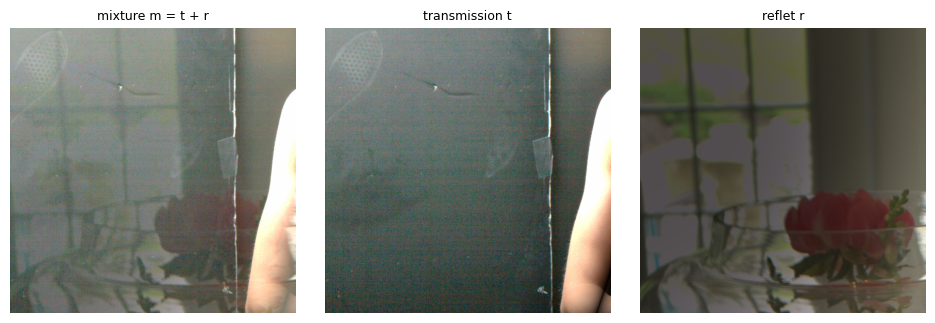

In [257]:
# Démo : on tire des paires réalistes jusqu'à trouver un mélange accepté
ex = None
for i in sat_pool[210:]:
    ia, ib = sample_realistic_pair(rnd)
    cand = simulate_example(pool[288], pool[i], rng)
    if is_useful(cand):
        ex = cand
        break
assert ex is not None, "aucun mélange accepté — relance la cellule"
print(f"t = {pool[i]['name']} ({pool[i]['loc']}), "
      f"r = {pool[288]['name']} ({pool[288]['loc']})")
show_row([ex["m"], ex["t"], ex["r"]],
         ["mixture m = t + r", "transmission t", "reflet r"])


In [256]:
(ex["m"] >=0.98).shape

(512, 512, 3)

## 4. Pipeline ISP : du linéaire au sRGB affichable

C'est elle qui va « finir » le dataset en JPEG. Pour un DNG complet (ou une
sortie de modèle en linéaire), il reste les étapes ACR 5–8 : balance des
blancs, conversion RGB, tone mapping, gamma. Version simplifiée :

1. **WB** : illuminant as-shot du DNG (fallback gray-world) + CAT Bradford
   → D50 — c'est le chemin « color matrices » de la spec DNG que le papier
   utilise (XYZ d'abord, WB ensuite) ;
2. **XYZ(D50) → sRGB linéaire** ;
3. **auto-exposition** : moyenne géométrique de la luminance → gris moyen
   (comme un posemètre) ;
4. **courbe de tons** : Reinhard étendu — remonte les ombres, roll-off doux
   des hautes lumières *(dans ACR : courbe propriétaire spatialement variable,
   c'est justement pourquoi on ne peut pas simuler des reflets sur des JPEG)* ;
5. **gamma sRGB** → 8 bits.


negatifs dans lin : 0.06%  dont B : 0.02%


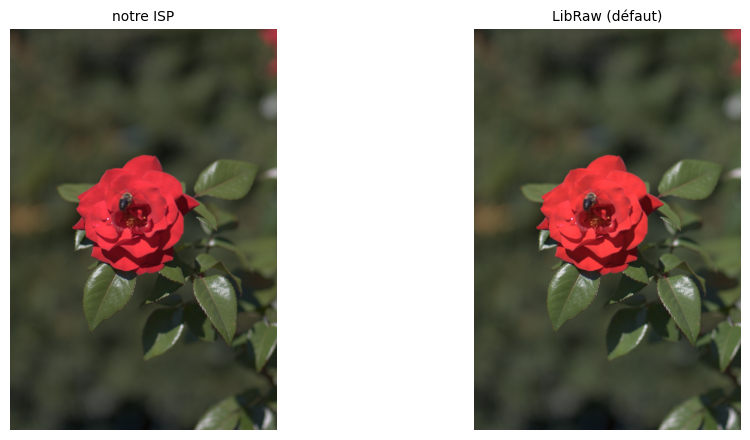

In [197]:
# bad for the photos, only useful in HDR lava floor
def tone_curve(x, white=4.0):
    """Reinhard étendu :0 x*(1 + x/white^2)/(1 + x)."""
    return x * (1.0 + x / white ** 2) / (1.0 + x)

def stats(x, nom="", vmax=1.0):
    """Distribution d'une image. vmax=1.0 si [0,1], vmax=255 si 8 bits."""
    x = np.asarray(x, np.float32)
    sat, noir = 0.99 * vmax, 0.004 * vmax
    q = np.percentile(x, [1, 25, 50, 75, 99])
    print(f"{nom}")
    print(f"   plage       min {x.min():8.4g}   max {x.max():8.4g}")
    print(f"   percentiles p1 {q[0]:.4g} | p25 {q[1]:.4g} | med {q[2]:.4g}"
          f" | p75 {q[3]:.4g} | p99 {q[4]:.4g}")
    for i, c in enumerate("RVB"):
        xi = x[..., i]
        print(f"   {c}   moyenne {xi.mean():8.4g}   saturé {(xi >= sat).mean():6.2%}"
              f"   bouché {(xi <= noir).mean():6.2%}")
    print(f"   au moins un canal saturé : {(x.max(-1) >= sat).mean():.2%}")
    print(f"   les trois canaux saturés : {(x.min(-1) >= sat).mean():.2%}")


def isp(lin_srgb, ev=0.0):
    """sRGB linéaire -> image 8 bits affichable."""
    x = np.clip(lin_srgb, 0, None) * 2.0 ** ev
    # if tone:
    #     x = tone_curve(x)
    # stats(x, "[0,1 my isp]",vmax=1)
    x = (srgb_encode(np.clip(x, 0, 1)) * 255 + 0.5).astype(np.uint8)
    return x


def dng_to_srgb(path, ev=0.0):
    """Pipeline complète DNG -> sRGB 8 bits."""
    xyz, illum, saturated = read_raw_to_xyz(path)
    lin = apply_matrix(xyz, XYZ_D50_TO_SRGB @ cat_matrix(illum))
    print(f"negatifs dans lin : {(lin < 0).mean():.2%}  dont B : {(lin[..., 2] < 0).mean():.2%}")

    # lin = auto_expose(np.clip(lin, 0, None))
    return isp(lin, ev=ev)


# Comparaison : notre ISP vs le rendu par défaut de LibRaw (WB appareil)
p = dng_files[14][0]
ours = dng_to_srgb(p)
with rawpy.imread(str(p)) as raw:
    ref = raw.postprocess(use_camera_wb=True, half_size=True, gamma=(2.4, 12.92))
    # stats(ref, "255 ref", vmax=255)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, img, title in zip(axes, [ours, ref], ["notre ISP", "LibRaw (défaut)"]):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [185]:
path = dng_files[14][0]
xyz, illum, saturated = read_raw_to_xyz(path)

In [186]:
saturated.sum()

np.int64(18)

## 5. Génération du dataset (JPEG sRGB)

Boucle : tirer une paire réaliste (`sample_realistic_pair`), simuler **en
linéaire**, filtrer, puis finir chaque composante avec la **même ISP**
(tone mapping + gamma, sans ré-exposition par composante pour rester
cohérent) et sauver `ex_XXXX_{m,t,r,c}.jpg`.

**Important** : après tone mapping, l'additivité `m = t + r` n'est **plus**
vérifiée — et c'est normal. Elle n'était nécessaire qu'au moment de la
synthèse, en linéaire. Le résultat : un dataset sRGB « comme des vraies
photos JPEG », mais dont le mélange sous-jacent était photométriquement
correct. (`SAVE_LINEAR = True` pour garder aussi les `.npz` linéaires,
par exemple pour entraîner plus tard un modèle RAW comme celui du papier.)


In [207]:
20000 * 8/500

320.0

In [226]:
CULL_SIZE = 256

def measure(exa):
    """Toutes les quantités de tri en une passe, plus le premier critère qui échoue.
    Remplace is_useful : is_useful(ex) <=> measure(ex)["verdict"] == "ok"."""
    rs = lambda x: cv2.resize(x, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    mc, tc, rc = rs(exa["m"]), rs(exa["t"]), rs(exa["r"])
    Ym, Yt, Yr = luminance(mc), luminance(tc), luminance(rc)
    ssim_m_tt, std_m_tt = ssim_fast(mc, tc)

    d = {"ssim": ssim_m_tt, "ssim_std": std_m_tt,
         "m_mean": float(m.mean()), "Ym": float(Ym.mean()),
         "vis": float(Yr.mean() / (Ym.mean() + 1e-8)),
         "t_std": float(Yt.std()), "r_std": float(Yr.std()),
         # pas un critere chez toi : on l'enregistre pour voir s'il apporterait qqch
         "sat_frac": float((m.max(axis=-1) > 0.99).mean())}

    if   not 0.40 < d["ssim"] < 0.94:  d["verdict"] = "ssim"
    elif d["ssim_std"] < 0.05:         d["verdict"] = "ssim_std"
    elif d["m_mean"] >= 0.7:           d["verdict"] = "m_mean"
    elif not 0.04 < d["Ym"] < 0.6:     d["verdict"] = "exposition"
    elif not 0.04 < d["vis"] < 0.6:    d["verdict"] = "visibilite"
    elif d["t_std"] < 0.015:           d["verdict"] = "t_plat"
    elif d["r_std"] < 0.008:           d["verdict"] = "r_plat"
    else:                              d["verdict"] = "ok"
    return d

def is_useful(exa):
    return measure(exa)["verdict"] == "ok"



In [229]:
def save_jpeg(path, lin_srgb):
    img = isp(lin_srgb)                    # tone mapping + gamma sRGB partagés
    cv2.imwrite(str(path), img[..., ::-1],
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

rows = []
n_saved = n_tried = 0
pbar = tqdm(total=N_EXAMPLES, desc="simulation")
while n_saved < N_EXAMPLES and n_tried < 200 * N_EXAMPLES:
    n_tried += 1
    ia, ib = sample_realistic_pair(rnd)
    ex = simulate_example(pool[ia], pool[ib], rng)
    d = measure(ex)
    d.update(t_name=pool[ia]["name"], r_name=pool[ib]["name"],
             t_loc=pool[ia]["loc"],   r_loc=pool[ib]["loc"])
    rows.append(d)
    if d["verdict"] != "ok":
        continue
    stem = f"ex_{n_saved:04d}"
    for k in "mtr":
        save_jpeg(OUT_DIR / f"{stem}_{k}.jpg", ex[k])
    if SAVE_LINEAR:
        np.savez_compressed(OUT_DIR / f"{stem}.npz",
                            **{k: v.astype(np.float16) for k, v in ex.items()},
                            t_name=pool[ia]["name"], r_name=pool[ib]["name"])
    n_saved += 1
    pbar.update(1)
pbar.close()
print(f"{n_saved} exemples acceptés sur {n_tried} essais "
      f"({n_saved / max(n_tried, 1):.0%} d'acceptation) -> {OUT_DIR}")


simulation:   0%|          | 0/500 [00:00<?, ?it/s]

500 exemples acceptés sur 3159 essais (16% d'acceptation) -> fivek_data/simulated


In [212]:
import pandas as pd

In [230]:

d1 = measure(simulate_example(pool[4], pool[80], np.random.default_rng(1)))
d2 = measure(simulate_example(pool[2], pool[3], np.random.default_rng(2)))
print(d1["ssim"], d2["ssim"])

0.9987321022137651 0.9946671719121074


In [231]:
df = pd.DataFrame(rows)
df.to_parquet(OUT_DIR / "trials.parquet")

print(df["verdict"].value_counts(normalize=True).mul(100).round(1))
print(df.loc[df.verdict == "ok"].describe().round(4))

# ce que la fraction saturee ajouterait, si tu l'activais comme critere
ok = df.verdict == "ok"
print(f"parmi les acceptes, {(df.loc[ok, 'sat_frac'] > 0.08).mean():.1%} depassent 8% de pixels ecretes")


verdict
ssim          74.6
ok            15.8
visibilite     6.6
exposition     2.5
r_plat         0.3
t_plat         0.1
Name: proportion, dtype: float64
           ssim  ssim_std    m_mean        Ym       vis     t_std     r_std  \
count  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000   
mean     0.7467    0.2320    0.1329    0.1990    0.3312    0.1276    0.0663   
std      0.1363    0.0737    0.0000    0.1295    0.1519    0.0920    0.0602   
min      0.4002    0.0621    0.1329    0.0799    0.0485    0.0151    0.0082   
25%      0.6448    0.1711    0.1329    0.1294    0.1993    0.0617    0.0255   
50%      0.7709    0.2331    0.1329    0.1348    0.3189    0.0989    0.0463   
75%      0.8627    0.2896    0.1329    0.1989    0.4604    0.1571    0.0818   
max      0.9390    0.4093    0.1329    0.5980    0.5995    0.4601    0.3348   

       sat_frac  
count     500.0  
mean        0.0  
std         0.0  
min         0.0  
25%         0.0  
50%         0.0  
75%    

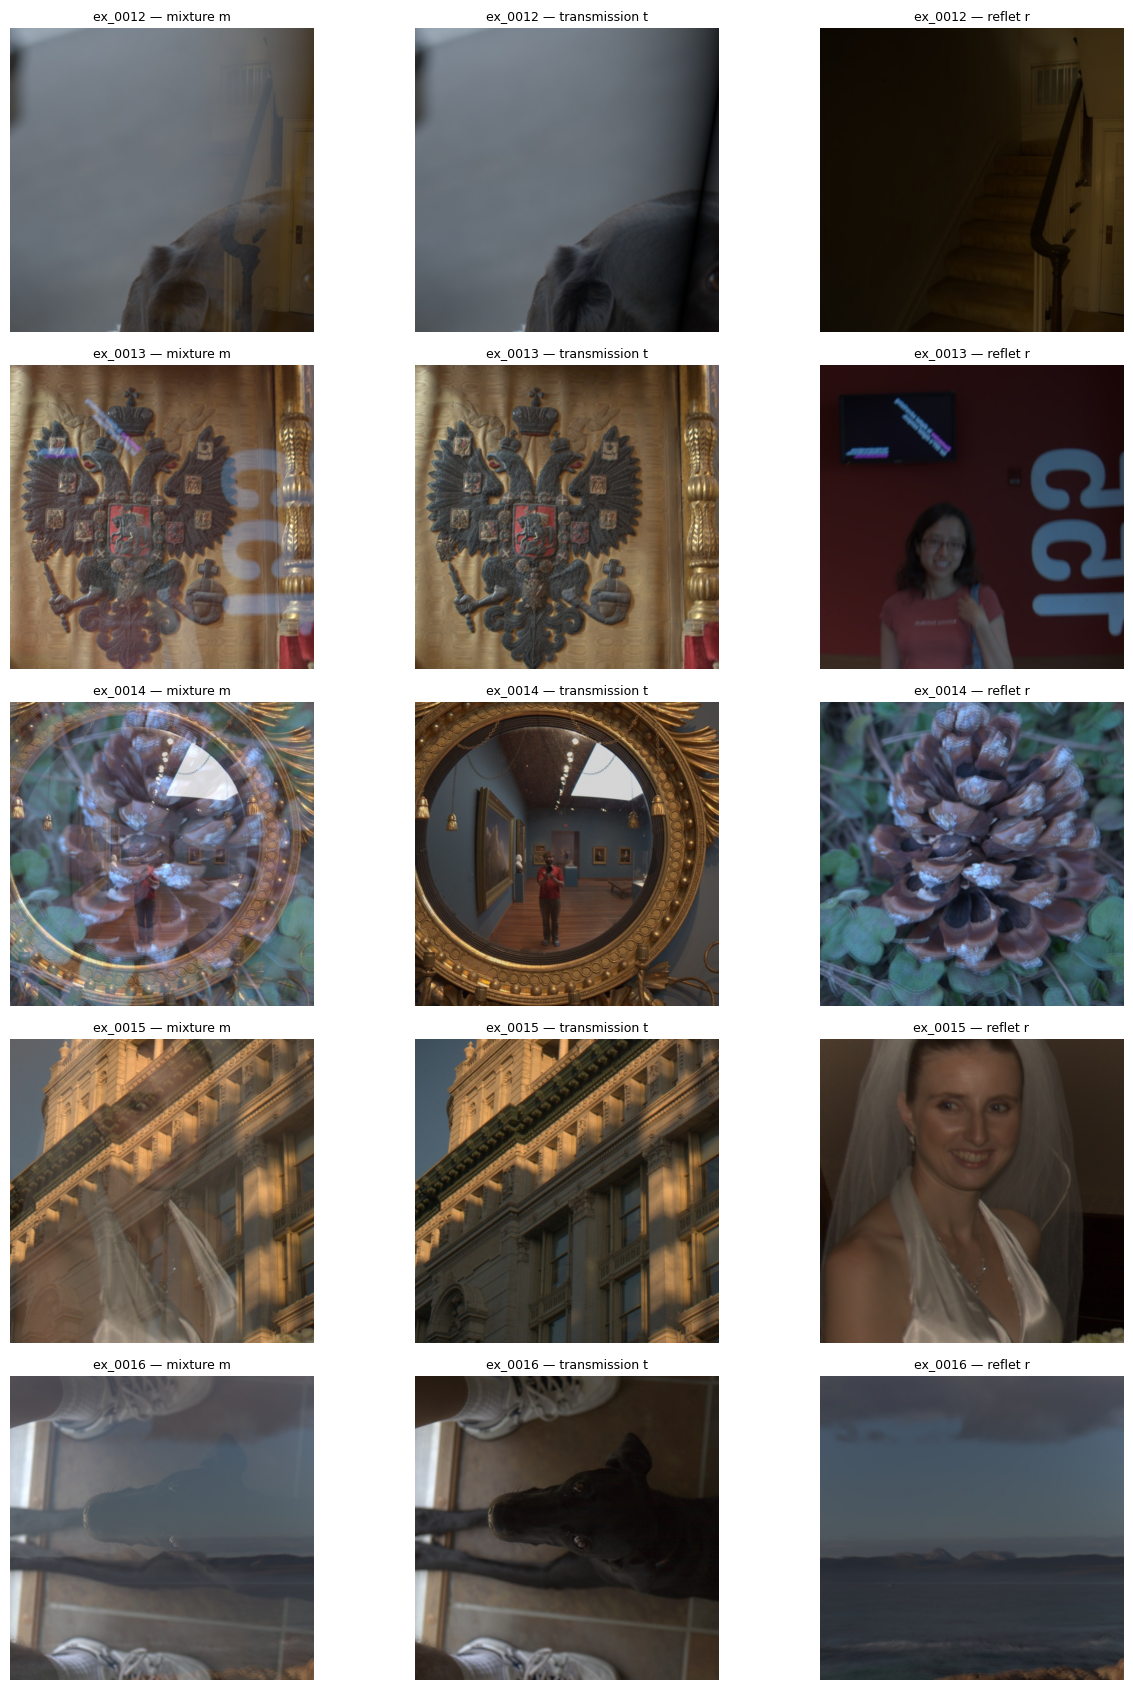

In [232]:
def show_examples(n=3, root=None, start=0):
    """Affiche n exemples du dataset JPEG : une ligne (m | t | r | c) chacun.

    n     : nombre d'exemples à afficher
    root  : dossier des JPEG (OUT_DIR par défaut)
    start : index du premier exemple (pour paginer : show_examples(3, start=3))
    """
    root = Path(root) if root else OUT_DIR
    stems = sorted({p.name[:-6] for p in root.glob("ex_*_m.jpg")})[start:start + n]
    if not stems:
        print(f"aucun exemple trouvé dans {root}")
        return
    titles = ["mixture m", "transmission t", "reflet r", "contexte c"]
    fig, axes = plt.subplots(len(stems), 3, figsize=(13, 3.4 * len(stems)),
                             squeeze=False)
    for row, stem in zip(axes, stems):
        for ax, k, title in zip(row, "mtr", titles):
            img = cv2.imread(str(root / f"{stem}_{k}.jpg"))
            ax.imshow(img[..., ::-1])
            ax.set_title(f"{stem} — {title}", fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(5, start=12)


## 6. Dataset PyTorch pour l'entraînement

Le modèle de base du papier prend `(m, c)` en entrée et prédit `(t, r)`
indépendamment (sans imposer `t + r = m`, pour découpler les échecs).
Ci-dessous : un `Dataset` qui charge les JPEG en `[0,1]`, avec crop et flip
aléatoires. La dernière vérification illustre que l'additivité ne tient plus
en sRGB tone-mappé — attendu, la physique a déjà joué son rôle à la synthèse.
Note : depuis l'ajout de l'atténuation `(1-R)`, `t` est la transmission *à
travers la vitre* — c'est bien elle qu'on veut récupérer.


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset


class FiveKReflections(Dataset):
    """(mixture, context) -> (transmission, reflection), en sRGB [0,1]."""

    def __init__(self, root, patch=224, train=True):
        self.root = Path(root)
        self.stems = sorted(p.name[:-6] for p in self.root.glob("ex_*_m.jpg"))
        self.patch = patch
        self.train = train

    def _load(self, stem, k):
        img = cv2.imread(str(self.root / f"{stem}_{k}.jpg"))
        return img[..., ::-1].astype(np.float32) / 255.0

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        m, t, r, c = (self._load(stem, k) for k in "mtrc")
        if self.train:
            p = self.patch
            y = np.random.randint(0, m.shape[0] - p + 1)
            x = np.random.randint(0, m.shape[1] - p + 1)
            m, t, r = (a[y:y + p, x:x + p] for a in (m, t, r))
            c = cv2.resize(c, (p, p), interpolation=cv2.INTER_AREA)
            if np.random.rand() < 0.5:
                m, t, r, c = (a[:, ::-1] for a in (m, t, r, c))
        to_tensor = lambda a: torch.from_numpy(np.ascontiguousarray(a)).permute(2, 0, 1)
        return {"mixture": to_tensor(m), "context": to_tensor(c),
                "transmission": to_tensor(t), "reflection": to_tensor(r)}


ds = FiveKReflections(OUT_DIR)
batch = next(iter(DataLoader(ds, batch_size=min(4, len(ds)), shuffle=True)))
print({k: tuple(v.shape) for k, v in batch.items()})

# En sRGB tone-mappé l'additivité n'est PLUS vérifiée — attendu : le tone
# mapping est non linéaire. Elle n'était requise qu'à la synthèse, en linéaire.
m, t, r = (ds._load(ds.stems[0], k) for k in "mtr")
diff = np.abs(np.clip(t + r, 0, 1) - m)
print(f"|m - clip(t+r)| en sRGB : moyenne = {diff.mean():.3f} (non nul, normal)")


{'mixture': (4, 3, 224, 224), 'context': (4, 3, 224, 224), 'transmission': (4, 3, 224, 224), 'reflection': (4, 3, 224, 224)}
|m - clip(t+r)| en sRGB : moyenne = 0.102 (non nul, normal)


## 7. Ce qui manque par rapport au papier — et pistes pour la suite

**Simplifications restantes** :
- **Échelle** : eux utilisent ~25 000 sources (MIT5K + RAISE + panoramas Laval
  Indoor) et cherchent parmi 10⁸ candidats ; nous, quelques DNG FiveK, un
  score de paires et un ratio de puissance échantillonné (`NORMALIZE_POWER`).
- **Géométrie** : une seule vitre plane et une homographie de rotation pour la
  perspective — pas la vraie projection double (caméra virtuelle derrière le
  miroir) ni les poses contraintes de la Sec. B ; Fresnel par rayon mais
  vitre non polarisante idéale (pas de teinte, saleté, rayures).
- **Couleur** : illuminant as-shot du DNG au lieu de la WB ACR complète
  (Func. S2/S9), matrice `ColorMatrix` seule au lieu de l'interpolation
  entre les deux illuminants de calibration de la spec DNG.
- **Ré-exposition** : pas de règle de saturation (Func. S1) — on filtre au
  lieu de préserver les pixels saturés.
- Pas d'écriture DNG des sorties, pas de modèle 2048p ni d'upsampler.

**Pistes pour ton projet de reflection removal** :
1. **Monte en volume** : augmente `N_OUTDOOR/N_INDOOR` (les 5 000 DNG ≈ 50 Go),
   génère 10-100k exemples ; le papier montre que la qualité des données RAW
   compte plus que l'architecture (+40 pts SSIM vs ~20 pts entre modèles).
2. **Entraîne un premier modèle** : U-Net léger qui prend `m` (et `c` en
   modulation par canal, à la StyleGAN) et prédit `(t, r)` — pertes L1 +
   perceptuelle (VGG) directement sur les JPEG en `[0,1]`. Le message du
   papier reste valable en sRGB : ce qui compte, c'est que le *mélange* ait
   été simulé physiquement en RAW, pas le format d'entraînement. Si un jour
   tu veux un modèle RAW de bout en bout comme le leur, régénère avec
   `SAVE_LINEAR = True` et entraîne sur les `.npz` linéaires.
3. **Priors de saturation** : implémente la règle Func. S1 (garder saturé ce
   qui est saturé) — le papier note que le vrai problème devient alors du
   *hole filling*.
4. **Expert TIFF16** : FiveK fournit 5 retouches expertes par image
   (`urls["tiff16"]["c"]`) — utile si tu veux aussi apprendre une ISP neurale
   (RAW → rendu expert) au lieu de notre ISP à la main.
5. **Upsampler** : le papier traite à 256p puis upsample par masquage de
   features sur pyramide gaussienne (Sec. 4.2) — indispensable si tu veux des
   sorties pleine résolution.
